# Stage 1: Dataset Exploration and Preprocessing

This notebook covers the initial stage of the machine learning pipeline, including dataset loading, exploration, visualization, and preprocessing.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
import warnings
from sklearn.model_selection import train_test_split
import pickle

warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Configure visualization settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

## 1. Load and Explore the Dataset

In [2]:
# Define dataset path
dataset_path = Path('food_subset2')

# Get all class directories
classes = sorted([d.name for d in dataset_path.iterdir() if d.is_dir()])

print(f"Number of classes: {len(classes)}")
print(f"Classes: {classes}\n")

# Load dataset information
data_info = {}
for class_name in classes:
    class_path = dataset_path / class_name
    images = sorted(list(class_path.glob('*.jpg')))
    data_info[class_name] = len(images)

print("Dataset Overview")

print(f"\nNumber of images per class:")
for class_name, count in data_info.items():
    print(f"{class_name}: {count}")

total_images = sum(data_info.values())
print(f"\nTotal number of images: {total_images}")
print(f"Average images per class: {total_images / len(classes):.2f}")

Number of classes: 5
Classes: ['donuts', 'falafel', 'ice_cream', 'pizza', 'spaghetti_bolognese']

Dataset Overview

Number of images per class:
donuts: 1000
falafel: 1000
ice_cream: 1000
pizza: 1000
spaghetti_bolognese: 1000

Total number of images: 5000
Average images per class: 1000.00


## 2. Display Sample Images

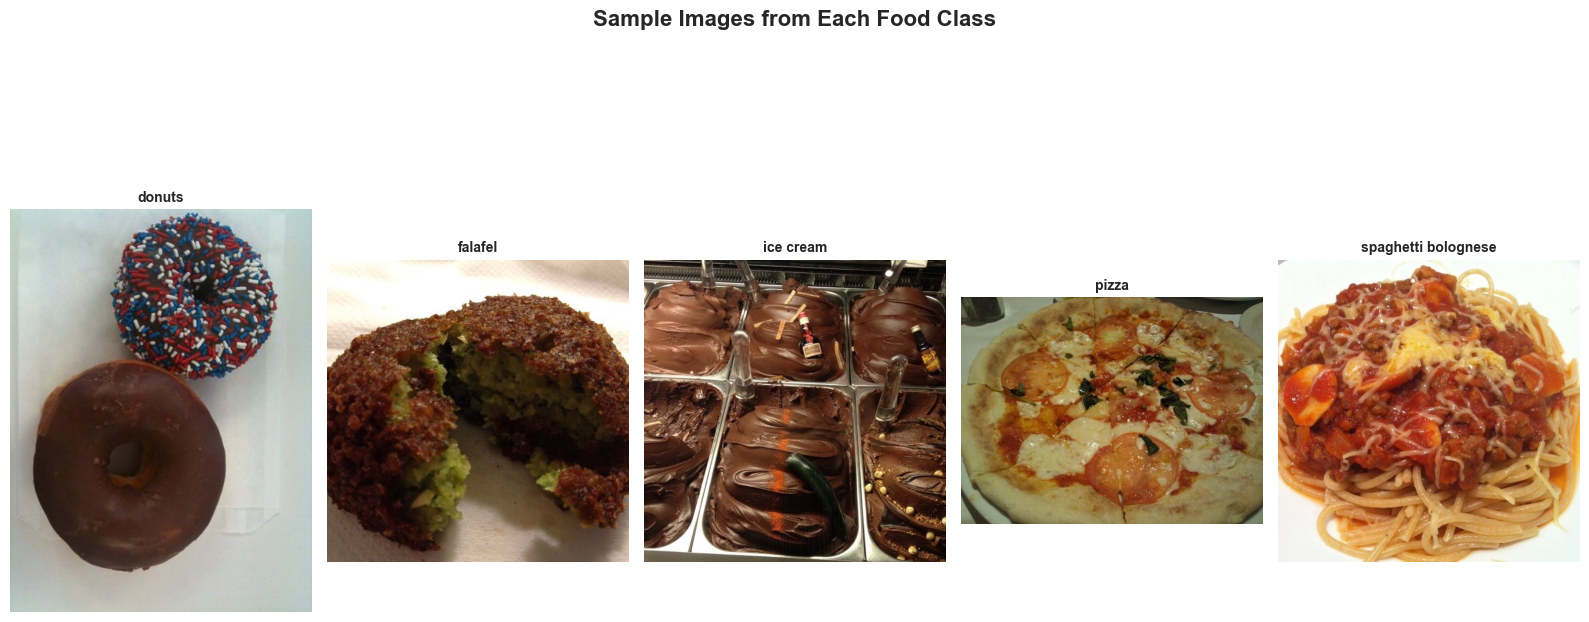

In [6]:
# Display sample images from each class
fig, axes = plt.subplots(1, 5, figsize=(16, 8))
fig.suptitle('Sample Images from Each Food Class', fontsize=16, fontweight='bold')

axes = axes.flatten()

for idx, class_name in enumerate(classes):
    class_path = dataset_path / class_name
    images = sorted(list(class_path.glob('*.jpg')))
    if images:
        # Load first image from the class
        img = Image.open(images[1])
        axes[idx].imshow(img)
        axes[idx].set_title(class_name.replace('_', ' '), fontsize=10, fontweight='bold')
        axes[idx].axis('off')

plt.tight_layout()
plt.show()

## 3. Analyze Class Distribution

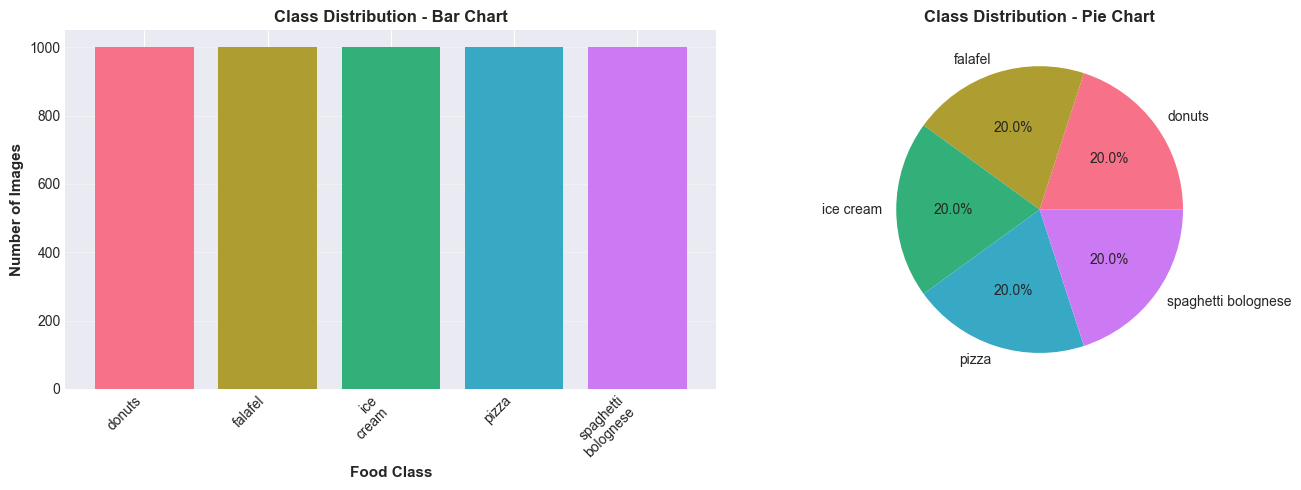

Class Distribution Statistics:

Min images in a class: 1000
Max images in a class: 1000
Mean images per class: 1000.00
Std deviation: 0.00
Class balance ratio (max/min): 1.00


In [7]:
# Create visualizations for class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
class_names = list(data_info.keys())
class_counts = list(data_info.values())

axes[0].bar(range(len(class_names)), class_counts, color=sns.color_palette("husl", len(class_names)))
axes[0].set_xlabel('Food Class', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Number of Images', fontsize=11, fontweight='bold')
axes[0].set_title('Class Distribution - Bar Chart', fontsize=12, fontweight='bold')
axes[0].set_xticks(range(len(class_names)))
axes[0].set_xticklabels([name.replace('_', '\n') for name in class_names], rotation=45, ha='right')
axes[0].grid(axis='y', alpha=0.3)

# Pie chart
axes[1].pie(class_counts, labels=[name.replace('_', ' ') for name in class_names], autopct='%1.1f%%',
            colors=sns.color_palette("husl", len(class_names)))
axes[1].set_title('Class Distribution - Pie Chart', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# Print class balance statistics
print("Class Distribution Statistics:\n")
counts = np.array(class_counts)
print(f"Min images in a class: {counts.min()}")
print(f"Max images in a class: {counts.max()}")
print(f"Mean images per class: {counts.mean():.2f}")
print(f"Std deviation: {counts.std():.2f}")
print(f"Class balance ratio (max/min): {counts.max() / counts.min():.2f}")

## 4. Load and Resize Images

In [8]:
# Define target image size for resizing
TARGET_SIZE = 128  # Smaller size for faster and more stable training

# Function to load and resize images
def load_and_resize_images(dataset_path, classes, target_size=224):
    # Load all images from the dataset and resize them to target size.
    # Returns: images (array), labels (array), class_names (list)
    images = []
    labels = []
    
    for class_idx, class_name in enumerate(classes):
        class_path = dataset_path / class_name
        image_files = sorted(list(class_path.glob('*.jpg')))
        
        for img_path in image_files:
            try:
                # Load image
                img = Image.open(img_path).convert('RGB')
                # Resize image
                img_resized = img.resize((target_size, target_size), Image.LANCZOS)
                # Convert to numpy array
                img_array = np.array(img_resized)
                
                images.append(img_array)
                labels.append(class_idx)
            except Exception as e:
                print(f"Error processing {img_path}: {e}")
                continue
        
        class_loaded_count = np.sum(np.array(labels) == class_idx)
        print(f"Loaded {class_loaded_count} images for class '{class_name}'")
    
    return np.array(images), np.array(labels), classes

# Load and resize images
X, y, class_names = load_and_resize_images(dataset_path, classes, TARGET_SIZE)


print("\nDataset Loaded and Resized")

print(f"Dataset shape: {X.shape}")
print(f"Labels shape: {y.shape}")
print(f"Image dimensions: {TARGET_SIZE}x{TARGET_SIZE}x3 (RGB)")
print(f"Unique classes: {np.unique(y)}")

Loaded 1000 images for class 'donuts'
Loaded 1000 images for class 'falafel'
Loaded 1000 images for class 'ice_cream'
Loaded 1000 images for class 'pizza'
Loaded 1000 images for class 'spaghetti_bolognese'

Dataset Loaded and Resized
Dataset shape: (5000, 128, 128, 3)
Labels shape: (5000,)
Image dimensions: 128x128x3 (RGB)
Unique classes: [0 1 2 3 4]


## 5. Normalize Pixel Values

Original pixel value statistics:
  Min value: 0
  Max value: 255
  Mean value: 114.14
  Std deviation: 72.10

Normalized pixel value statistics (0-1 range):
  Min value: 0.0000
  Max value: 1.0000
  Mean value: 0.4476
  Std deviation: 0.2827


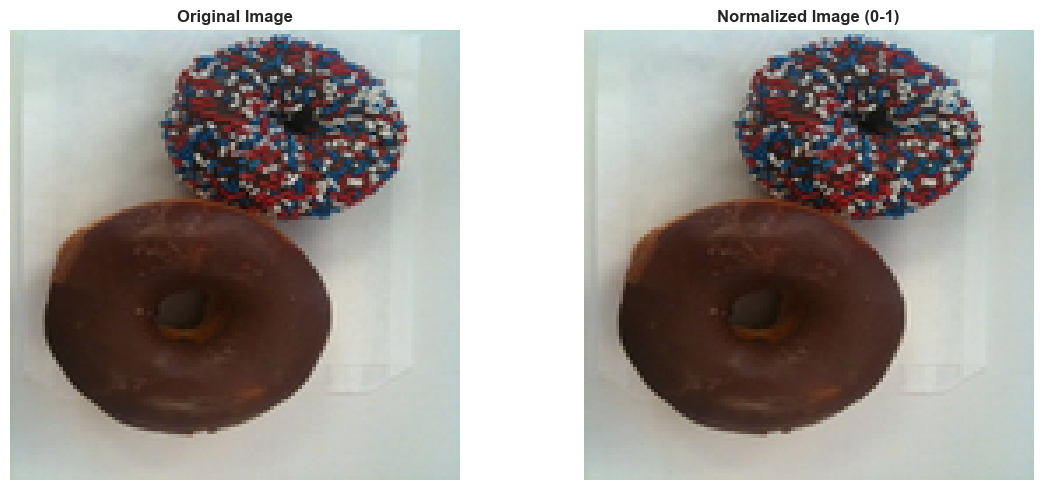

In [10]:
# Display original pixel value statistics
print("Original pixel value statistics:")
print(f"  Min value: {X.min()}")
print(f"  Max value: {X.max()}")
print(f"  Mean value: {X.mean():.2f}")
print(f"  Std deviation: {X.std():.2f}")

# Normalize pixel values to 0-1 range
X_normalized = X.astype('float32') / 255.0

# Display normalized pixel value statistics
print("\nNormalized pixel value statistics (0-1 range):")
print(f"  Min value: {X_normalized.min():.4f}")
print(f"  Max value: {X_normalized.max():.4f}")
print(f"  Mean value: {X_normalized.mean():.4f}")
print(f"  Std deviation: {X_normalized.std():.4f}")

# Visualize effect of normalization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Original image
sample_idx = 1
axes[0].imshow(X[sample_idx].astype('uint8'))
axes[0].set_title('Original Image', fontsize=12, fontweight='bold')
axes[0].axis('off')

# Normalized image
axes[1].imshow(X_normalized[sample_idx])
axes[1].set_title('Normalized Image (0-1)', fontsize=12, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()

## 6. Split Data into Training, Validation, and Testing Sets

In [11]:
# Define split ratios
TRAIN_SIZE = 0.70
VAL_SIZE = 0.15
TEST_SIZE = 0.15

# First split: separate test set (15%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X_normalized, y, test_size=TEST_SIZE, random_state=42, stratify=y
)

# Second split: separate train and validation from remaining data (70% train, 15% val)
val_size_adjusted = VAL_SIZE / (1 - TEST_SIZE)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=val_size_adjusted, random_state=42, stratify=y_temp
)

print("Data Split Summary:\n")
print(f"\nTotal dataset size: {len(X_normalized):,} images")
print(f"\nTraining set size: {len(X_train):,} images ({len(X_train)/len(X_normalized)*100:.1f}%)")
print(f"Validation set size: {len(X_val):,} images ({len(X_val)/len(X_normalized)*100:.1f}%)")
print(f"Testing set size: {len(X_test):,} images ({len(X_test)/len(X_normalized)*100:.1f}%)")

# Verify label distribution in each split
print("\nLabel Distribution Across Splits:")


for set_name, y_set in [("Training", y_train), ("Validation", y_val), ("Testing", y_test)]:
    print(f"\n{set_name} set label distribution:")
    unique, counts = np.unique(y_set, return_counts=True)
    for label_idx, count in zip(unique, counts):
        print(f"  {class_names[label_idx]}: {count} images")

Data Split Summary:


Total dataset size: 5,000 images

Training set size: 3,500 images (70.0%)
Validation set size: 750 images (15.0%)
Testing set size: 750 images (15.0%)

Label Distribution Across Splits:

Training set label distribution:
  donuts: 700 images
  falafel: 700 images
  ice_cream: 700 images
  pizza: 700 images
  spaghetti_bolognese: 700 images

Validation set label distribution:
  donuts: 150 images
  falafel: 150 images
  ice_cream: 150 images
  pizza: 150 images
  spaghetti_bolognese: 150 images

Testing set label distribution:
  donuts: 150 images
  falafel: 150 images
  ice_cream: 150 images
  pizza: 150 images
  spaghetti_bolognese: 150 images


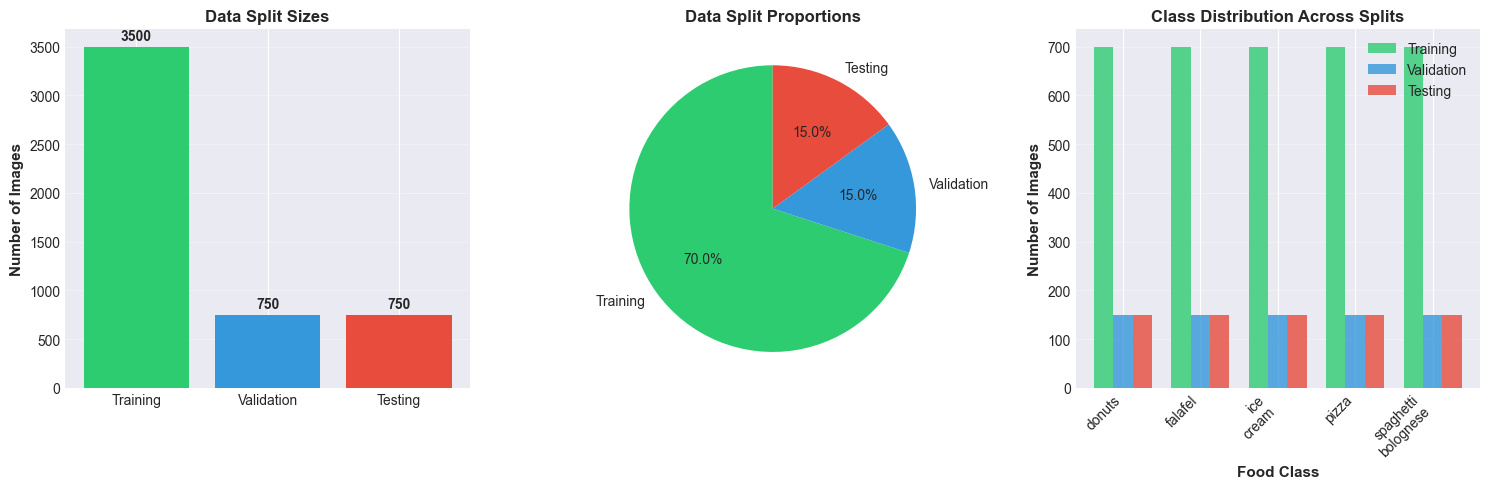

In [12]:
# Visualize the data split
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
split_names = ['Training', 'Validation', 'Testing']
split_sizes = [len(X_train), len(X_val), len(X_test)]
colors = ['#2ecc71', '#3498db', '#e74c3c']

# Bar chart of split sizes
axes[0].bar(split_names, split_sizes, color=colors)
axes[0].set_ylabel('Number of Images', fontsize=11, fontweight='bold')
axes[0].set_title('Data Split Sizes', fontsize=12, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)
for i, v in enumerate(split_sizes):
    axes[0].text(i, v + max(split_sizes)*0.02, str(v), ha='center', fontweight='bold')

# Pie chart of split proportions
axes[1].pie(split_sizes, labels=split_names, autopct='%1.1f%%', colors=colors, startangle=90)
axes[1].set_title('Data Split Proportions', fontsize=12, fontweight='bold')

# Class distribution in train/val/test
y_sets = [y_train, y_val, y_test]
x_pos = np.arange(len(class_names))
width = 0.25

for i, (y_set, set_name, color) in enumerate(zip(y_sets, split_names, colors)):
    _, counts = np.unique(y_set, return_counts=True)
    axes[2].bar(x_pos + i*width, counts, width, label=set_name, color=color, alpha=0.8)

axes[2].set_xlabel('Food Class', fontsize=11, fontweight='bold')
axes[2].set_ylabel('Number of Images', fontsize=11, fontweight='bold')
axes[2].set_title('Class Distribution Across Splits', fontsize=12, fontweight='bold')
axes[2].set_xticks(x_pos + width)
axes[2].set_xticklabels([name.replace('_', '\n') for name in class_names], rotation=45, ha='right')
axes[2].legend()
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [13]:
# Summary statistics
print("Final Dataset Summary:\n")
print(f"\nNumber of classes: {len(class_names)}")
print(f"Classes: {', '.join(class_names)}")
print(f"\nImage dimensions: {TARGET_SIZE}x{TARGET_SIZE}x3 (RGB)")
print(f"Pixel value range: [0.0, 1.0] (normalized)")
print(f"\nTraining set: {X_train.shape}")
print(f"Validation set: {X_val.shape}")
print(f"Testing set: {X_test.shape}")
print(f"\nMemory usage:")
print(f"  Training: {X_train.nbytes / (1024**2):.2f} MB")
print(f"  Validation: {X_val.nbytes / (1024**2):.2f} MB")
print(f"  Testing: {X_test.nbytes / (1024**2):.2f} MB")
print(f"  Total: {(X_train.nbytes + X_val.nbytes + X_test.nbytes) / (1024**2):.2f} MB")

Final Dataset Summary:


Number of classes: 5
Classes: donuts, falafel, ice_cream, pizza, spaghetti_bolognese

Image dimensions: 128x128x3 (RGB)
Pixel value range: [0.0, 1.0] (normalized)

Training set: (3500, 128, 128, 3)
Validation set: (750, 128, 128, 3)
Testing set: (750, 128, 128, 3)

Memory usage:
  Training: 656.25 MB
  Validation: 140.62 MB
  Testing: 140.62 MB
  Total: 937.50 MB


# Stage 2: Build a Custom CNN from Scratch

2026-05-09 18:05:23.562737: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Max
2026-05-09 18:05:23.562769: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 48.00 GB
2026-05-09 18:05:23.562774: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 18.72 GB
2026-05-09 18:05:23.562786: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-05-09 18:05:23.562795: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,288,325 (16.36 MB)

 Trainable params: 4,288,325 (16.36 MB)

 Non-trainable params: 0 (0.00 B)


Total trainable parameters: 4,288,325
Epoch 1/30


2026-05-09 18:05:24.948707: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


110/110 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.3523 - loss: 1.5132 - val_accuracy: 0.4267 - val_loss: 1.3860
Epoch 2/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.4369 - loss: 1.3595 - val_accuracy: 0.4640 - val_loss: 1.3186
Epoch 3/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.5077 - loss: 1.2316 - val_accuracy: 0.4987 - val_loss: 1.3248
Epoch 4/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.5451 - loss: 1.1472 - val_accuracy: 0.4480 - val_loss: 1.6306
Epoch 5/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.5694 - loss: 1.1061 - val_accuracy: 0.4427 - val_loss: 1.7554
Epoch 6/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.5957 - loss: 1.0941 - val_accuracy: 0.4587 - val_loss: 1.5066
Epoch 7/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.6171 - loss: 1.0606 - val_accuracy: 0.3893 - val_loss: 2.8067
Epoch 8/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.6523 - loss: 0.9999 - val_accuracy: 0.422

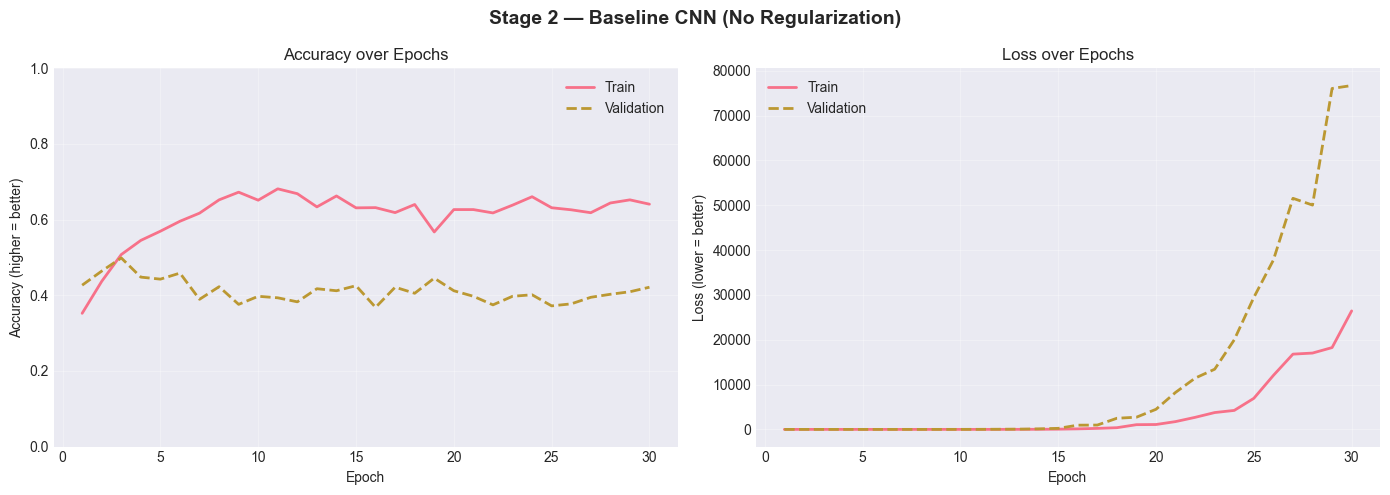

Stage 2 — Baseline CNN Results

Training accuracy: 64.1%  (on training data)
Validation accuracy: 42.1%  (on unseen validation data)
Best val accuracy: 49.9%  (highest reached during training)
Test accuracy: 43.3%  (on held-out test data)

  Overfitting gap (train − val): 22.0%


In [14]:
# Stage 2: Custom CNN from scratch — baseline (no regularization)
import tensorflow as tf
from tensorflow.keras import layers, models

tf.random.set_seed(42)

# Build the CNN manually
custom_cnn = models.Sequential([
    layers.Input(shape=(TARGET_SIZE, TARGET_SIZE, 3)),

    # Block 1 — low-level features (edges, textures)
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    # Block 2 — mid-level features
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    # Block 3 — high-level food-specific features
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    # Convert feature maps to a vector
    layers.Flatten(),

    # Classifier head
    layers.Dense(128, activation='relu'),
    layers.Dense(len(class_names), activation='softmax')
])

custom_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Model summary and trainable parameters
custom_cnn.summary()
print(f'\nTotal trainable parameters: {custom_cnn.count_params():,}')

# Train
history = custom_cnn.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32,
    verbose=1
)

#Accuracy and loss curves
history_dict = history.history
epochs_range = range(1, len(history_dict['accuracy']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Stage 2 — Baseline CNN (No Regularization)', fontsize=14, fontweight='bold')

axes[0].plot(epochs_range, history_dict['accuracy'],     label='Train',      linewidth=2)
axes[0].plot(epochs_range, history_dict['val_accuracy'], label='Validation', linewidth=2, linestyle='--')
axes[0].set_title('Accuracy over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy (higher = better)')
axes[0].set_ylim(0, 1)
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, history_dict['loss'],     label='Train',      linewidth=2)
axes[1].plot(epochs_range, history_dict['val_loss'], label='Validation', linewidth=2, linestyle='--')
axes[1].set_title('Loss over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss (lower = better)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


val_loss, val_acc   = custom_cnn.evaluate(X_val,  y_val,  verbose=0)
test_loss, test_acc = custom_cnn.evaluate(X_test, y_test, verbose=0)
best_val_acc        = max(history_dict['val_accuracy'])
final_train_acc     = history_dict['accuracy'][-1]


print('Stage 2 — Baseline CNN Results\n')
print(f'Training accuracy: {final_train_acc*100:.1f}%  (on training data)')
print(f'Validation accuracy: {val_acc*100:.1f}%  (on unseen validation data)')
print(f'Best val accuracy: {best_val_acc*100:.1f}%  (highest reached during training)')
print(f'Test accuracy: {test_acc*100:.1f}%  (on held-out test data)')
gap = final_train_acc - val_acc
print(f'\n  Overfitting gap (train − val): {gap*100:.1f}%')

## Why CNNs are suitable for image classification
CNNs process images by scanning small local patches (kernels) across the entire image, so they naturally capture spatial patterns like edges, shapes, and textures regardless of where they appear. Fully connected networks would need to treat every pixel independently, leading to millions of parameters and poor generalization. CNNs share weights across positions, making them far more efficient and effective for images.

## Purpose of each layer
| Layer | Purpose |
|-------|---------|
| `Conv2D` | Applies learnable filters to extract visual features from the input. |
| `ReLU activation` | Introduces non-linearity so the network can learn complex decision boundaries. |
| `MaxPooling2D` | Downsamples feature maps, reducing size and computation while keeping the strongest activations. |
| `Flatten` | Converts the 2D feature maps into a 1D vector so Dense layers can process them. |
| `Dense` | Combines extracted features to form class-level decision boundaries. |
| `Softmax output` | Produces a probability distribution over the 10 food classes; the class with the highest probability is the prediction. |

## Trainable parameters
The model summary above lists the parameter count per layer. The total is reported after the summary.

# Stage 3: Regularization and Overfitting Prevention

In [18]:
# Stage 3: Regularized CNN — applying 4 techniques to fix overfitting
# Techniques used: Dropout, Batch Normalization, Early Stopping, Data Augmentation
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

tf.random.set_seed(42)

# Technique 3: Data Augmentation — show the model more variation per image
data_augmentation = models.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.10),
    layers.RandomZoom(0.10),
], name='augmentation')

# Regularized CNN (same 3-block architecture as Stage 2 baseline)
regularized_cnn = models.Sequential([
    layers.Input(shape=(TARGET_SIZE, TARGET_SIZE, 3)),
    data_augmentation,

    # Block 1
    layers.Conv2D(32, (3, 3), padding='same'),
    layers.BatchNormalization(),          # Technique 2: Batch Normalization
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),

    # Block 2
    layers.Conv2D(64, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),

    # Block 3
    layers.Conv2D(128, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dropout(0.6),
    # Technique 1: Dropout (40%) + Technique 4: L2 weight regularization
    layers.Dense(128, kernel_regularizer=regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.4),

    layers.Dense(len(class_names), activation='softmax')
])

regularized_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

regularized_cnn.summary()
print(f'\nTotal trainable parameters: {regularized_cnn.count_params():,}')

# Early Stopping: stop when val_accuracy stops improving (patience=15)
early_stop  = EarlyStopping(monitor='val_accuracy', patience=15, restore_best_weights=True, verbose=1)
# Reduce LR when training stagnates (helps with augmented data)
reduce_lr   = ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=4, min_lr=1e-6, verbose=1)

history_reg = regularized_cnn.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# Results
reg_dict = history_reg.history
val_loss_reg, val_acc_reg = regularized_cnn.evaluate(X_val,  y_val,  verbose=0)
test_loss_reg, test_acc_reg = regularized_cnn.evaluate(X_test, y_test, verbose=0)
best_val_reg = max(reg_dict['val_accuracy'])
final_train_reg = reg_dict['accuracy'][-1]

print('\nStage 3 — Regularized CNN Results:\n')
print(f'  Training accuracy   : {final_train_reg*100:.1f}%')
print(f'  Validation accuracy : {val_acc_reg*100:.1f}%')
print(f'  Best val accuracy   : {best_val_reg*100:.1f}%')
print(f'  Test accuracy       : {test_acc_reg*100:.1f}%')
gap_reg = final_train_reg - val_acc_reg
print(f'  Overfitting gap     : {gap_reg*100:.1f}%')

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ augmentation (Sequential)       │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_11 (Activation)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,289,733 (16.36 MB)

 Trainable params: 4,289,029 (16.36 MB)

 Non-trainable params: 704 (2.75 KB)


Total trainable parameters: 4,289,733
Epoch 1/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 7s 42ms/step - accuracy: 0.3986 - loss: 1.5701 - val_accuracy: 0.2000 - val_loss: 2.1917 - learning_rate: 0.0010
Epoch 2/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - accuracy: 0.4820 - loss: 1.3391 - val_accuracy: 0.2013 - val_loss: 2.5226 - learning_rate: 0.0010
Epoch 3/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - accuracy: 0.5386 - loss: 1.2160 - val_accuracy: 0.2387 - val_loss: 2.4162 - learning_rate: 0.0010
Epoch 4/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - accuracy: 0.5546 - loss: 1.1883 - val_accuracy: 0.5053 - val_loss: 1.3299 - learning_rate: 0.0010
Epoch 5/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - accuracy: 0.5886 - loss: 1.1176 - val_accuracy: 0.5427 - val_loss: 1.2635 - learning_rate: 0.0010
Epoch 6/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - accuracy: 0.6020 - loss: 1.0969 - val_accuracy: 0.4973 - val_loss: 1.3093 - learning_rate: 0.0010
Epoch 7/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 4s 

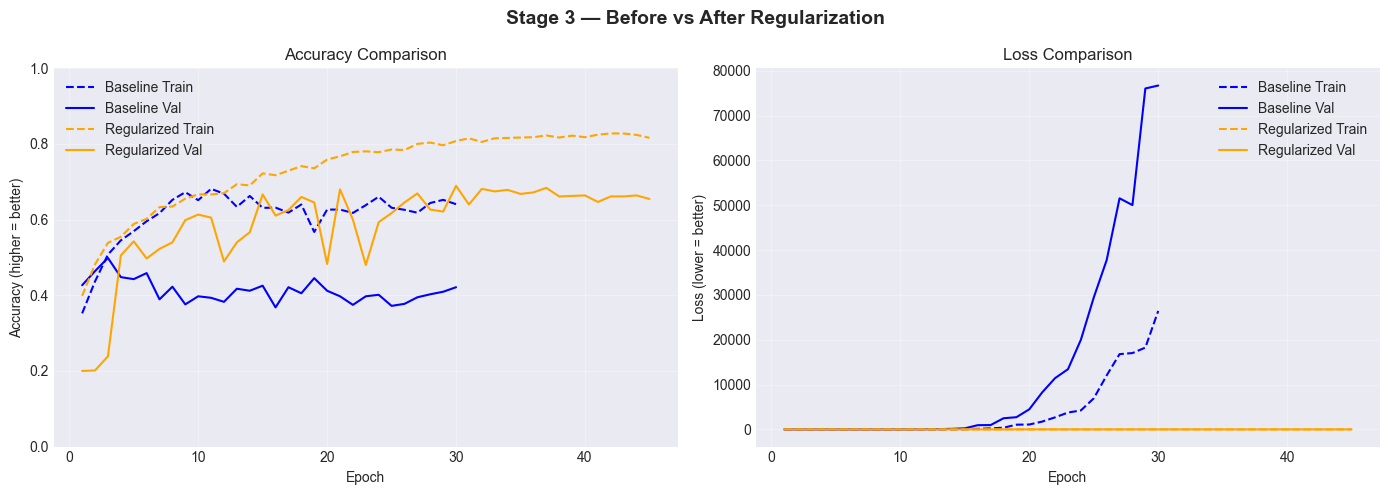


  Overfitting Analysis — Before vs After Regularization
  Metric                           Baseline  Regularized
------------------------------------------------------------
  Train accuracy                      64.1%        81.6%
  Validation accuracy                 42.1%        68.9%
  Test accuracy                       43.3%        69.5%
  Overfitting gap (train-val)         22.0%        12.7%

  Regularization reduced overfitting. The gap between
  training and validation accuracy is smaller.


In [19]:
# Stage 3: Before vs After Regularization comparison

baseline_epochs = range(1, len(history_dict['accuracy']) + 1)
reg_epochs      = range(1, len(reg_dict['accuracy']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Stage 3 — Before vs After Regularization', fontsize=14, fontweight='bold')

# Accuracy comparison
axes[0].plot(baseline_epochs, history_dict['accuracy'],     color='blue',   linestyle='--', label='Baseline Train')
axes[0].plot(baseline_epochs, history_dict['val_accuracy'], color='blue',   linestyle='-',  label='Baseline Val')
axes[0].plot(reg_epochs,      reg_dict['accuracy'],         color='orange', linestyle='--', label='Regularized Train')
axes[0].plot(reg_epochs,      reg_dict['val_accuracy'],     color='orange', linestyle='-',  label='Regularized Val')
axes[0].set_title('Accuracy Comparison')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy (higher = better)')
axes[0].set_ylim(0, 1)
axes[0].legend()
axes[0].grid(alpha=0.3)

# Loss comparison
axes[1].plot(baseline_epochs, history_dict['loss'],     color='blue',   linestyle='--', label='Baseline Train')
axes[1].plot(baseline_epochs, history_dict['val_loss'], color='blue',   linestyle='-',  label='Baseline Val')
axes[1].plot(reg_epochs,      reg_dict['loss'],         color='orange', linestyle='--', label='Regularized Train')
axes[1].plot(reg_epochs,      reg_dict['val_loss'],     color='orange', linestyle='-',  label='Regularized Val')
axes[1].set_title('Loss Comparison')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss (lower = better)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Overfitting analysis table
print('\n' + '='*60)
print('  Overfitting Analysis — Before vs After Regularization')
print('='*60)
print(f"  {'Metric':<30} {'Baseline':>10} {'Regularized':>12}")
print('-'*60)
print(f"  {'Train accuracy':<30} {final_train_acc*100:>9.1f}% {final_train_reg*100:>11.1f}%")
print(f"  {'Validation accuracy':<30} {val_acc*100:>9.1f}% {val_acc_reg*100:>11.1f}%")
print(f"  {'Test accuracy':<30} {test_acc*100:>9.1f}% {test_acc_reg*100:>11.1f}%")
print(f"  {'Overfitting gap (train-val)':<30} {(final_train_acc-val_acc)*100:>9.1f}% {(final_train_reg-val_acc_reg)*100:>11.1f}%")
print('='*60)

if (final_train_reg - val_acc_reg) < (final_train_acc - val_acc):
    print('\n  Regularization reduced overfitting. The gap between')
    print('  training and validation accuracy is smaller.')
else:
    print('\n  Note: model may need more epochs or tuning.')

## Regularization Techniques Applied

| Technique | What it does | Where applied |
|-----------|-------------|---------------|
| **Dropout (40%)** | Randomly disables 40% of neurons each training step, forcing the network not to rely on any single neuron. Reduces overfitting by making the model more robust. | After the Dense(128) layer |
| **Batch Normalization** | Normalizes the output of each layer so values stay in a stable range. This smooths training, speeds up convergence, and acts as a mild regularizer. | After every Conv2D and Dense layer |
| **Early Stopping** | Monitors **validation accuracy** and stops training when it no longer improves (`patience=8`). Restores the best weights seen so far. | Keras callback during training |
| **Data Augmentation** | Randomly flips, rotates, and zooms images so the model never sees the exact same image twice. Artificially increases training variety. | First layer of the model |
| **L2 Regularization** | Adds a penalty to the loss for large weights ($\lambda=10^{-4}$), pushing weights to stay small and discouraging memorization. | Dense(128) kernel |

## Why overfitting happened in Stage 2
In Stage 2 the model showed high variance: training accuracy increased notably while validation accuracy remained much lower, and validation loss became unstable at later epochs. This indicates overfitting: the model was learning training-specific patterns that did not generalize well.

## What regularization improved
By combining Dropout, Batch Normalization, Early Stopping, Data Augmentation, and L2, the model is encouraged to:
- Learn more general features (augmentation)
- Avoid relying on a small set of neurons (dropout)
- Keep weights smaller and smoother (L2)
- Train more stably (batch norm)
- Stop training once validation performance plateaus (early stopping)

# Stage 5: Transfer Learning Models

In [ ]:
# Stage 5 — Transfer Learning: imports, preprocessing & helpers
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import ResNet50, MobileNetV2, EfficientNetB0
from tensorflow.keras.applications.resnet50    import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess
from tensorflow.keras.applications.efficientnet import preprocess_input as effnet_preprocess
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

tf.random.set_seed(42)

NUM_CLASSES = len(class_names)
IMG_SIZE    = TARGET_SIZE  # 128 — pretrained models trained at 224; 128 trades
                            #       some accuracy for faster experimentation.

# ── Per-model preprocessing ──────────────────────────────────────────
# De-normalise from [0,1] → [0,255], then apply each model's canonical transform.
_raw = {split: arr * 255.0
        for split, arr in [('train', X_train), ('val', X_val), ('test', X_test)]}

tl_data = {
    'resnet50':       {s: resnet_preprocess(v.copy())   for s, v in _raw.items()},
    'mobilenetv2':    {s: mobilenet_preprocess(v.copy()) for s, v in _raw.items()},
    'efficientnetb0': {s: effnet_preprocess(v.copy())    for s, v in _raw.items()},
}

print('Preprocessing complete:')
for k in tl_data:
    print(f'  {k}: {tl_data[k]["train"].shape}')

# ── Helper: metrics ───────────────────────────────────────────────────
def get_metrics(model, X, y):
    """Return (accuracy, precision, recall, f1) weighted, on dataset (X, y)."""
    y_pred = np.argmax(model.predict(X, verbose=0), axis=1)
    acc = accuracy_score(y, y_pred)
    p, r, f1, _ = precision_recall_fscore_support(
        y, y_pred, average='weighted', zero_division=0)
    return float(acc), float(p), float(r), float(f1)

# ── Helper: parameter counts ─────────────────────────────────────────
def param_counts(model):
    """Return (total_params, trainable_params) as integers."""
    total     = int(model.count_params())
    trainable = int(sum(np.prod(v.shape) for v in model.trainable_variables))
    return total, trainable

# ── Helper: callbacks ────────────────────────────────────────────────
def make_callbacks(patience=6):
    return [
        EarlyStopping(monitor='val_accuracy', patience=patience,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_accuracy', factor=0.5,
                          patience=3, min_lr=1e-7, verbose=0),
    ]

# ── Results store ────────────────────────────────────────────────────
tl_results = {}

print('\nStage 5 setup complete — ready to train transfer learning models.')

Preprocessing complete:
  resnet50: (2800, 128, 128, 3)
  mobilenetv2: (2800, 128, 128, 3)
  efficientnetb0: (2800, 128, 128, 3)

Stage 5 setup complete — ready to train transfer learning models.


## Model 1 — ResNet50

ResNet50 is a 50-layer deep residual network (~23M parameters). Its skip connections allow very deep training without vanishing gradients, making it a strong general-purpose feature extractor.

**Two experiments:**
- **Exp A — Feature Extractor:** Freeze all 175 base layers; train only the new classification head.
- **Exp B — Fine-Tuning:** Warm up head for 5 epochs, then unfreeze the last convolutional block (conv5, ~53 layers) and retrain with LR = 1e-5.

In [ ]:
# ResNet50 — Experiment A: Pretrained Feature Extractor
print('ResNet50 — Experiment A: Pretrained Feature Extractor')
print('='*60)
print('  • Load ResNet50 with ImageNet weights')
print('  • Freeze entire base model (175 layers)')
print('  • Train only new classification head  (LR = 1e-3)\n')

# 1. Load pretrained base, freeze all layers
base_r50 = ResNet50(weights='imagenet', include_top=False,
                    input_shape=(IMG_SIZE, IMG_SIZE, 3))
base_r50.trainable = False

# 2. Add custom classification head
inp = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x   = base_r50(inp, training=False)   # training=False keeps BN in inference mode
x   = layers.GlobalAveragePooling2D()(x)
x   = layers.Dense(256, activation='relu')(x)
x   = layers.Dropout(0.3)(x)
out = layers.Dense(NUM_CLASSES, activation='softmax')(x)
model_r50_A = Model(inp, out, name='resnet50_feature_extractor')

total_r50, trainable_r50_A = param_counts(model_r50_A)
print(f'Total parameters  : {total_r50:,}')
print(f'Trainable params  : {trainable_r50_A:,}  ← classification head only')
print(f'Frozen params     : {total_r50 - trainable_r50_A:,}\n')

# 3. Compile — high LR is fine since only the head is trainable
model_r50_A.compile(
    optimizer=Adam(1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

t0 = time.time()
hist_r50_A = model_r50_A.fit(
    tl_data['resnet50']['train'], y_train,
    validation_data=(tl_data['resnet50']['val'], y_val),
    epochs=30, batch_size=32,
    callbacks=make_callbacks(patience=6),
    verbose=1,
)
time_r50_A = time.time() - t0

# 4. Evaluate on held-out test set
acc, p, r, f1 = get_metrics(model_r50_A, tl_data['resnet50']['test'], y_test)
best_val = max(hist_r50_A.history['val_accuracy'])

tl_results['ResNet50 — Exp A'] = {
    'model_label': 'ResNet50', 'experiment': 'Feature Extractor',
    'acc': acc, 'precision': p, 'recall': r, 'f1': f1,
    'best_val_acc': best_val, 'train_time': time_r50_A,
    'total_params': total_r50, 'trainable_params': trainable_r50_A,
    'history': hist_r50_A.history,
}

print(f'\n{"─"*55}')
print(f'  ResNet50 — Exp A Results')
print(f'{"─"*55}')
print(f'  Test Accuracy  : {acc*100:.1f}%')
print(f'  Precision      : {p*100:.1f}%')
print(f'  Recall         : {r*100:.1f}%')
print(f'  F1-score       : {f1*100:.1f}%')
print(f'  Best Val Acc   : {best_val*100:.1f}%')
print(f'  Training time  : {time_r50_A:.0f}s')
print(f'  Trainable param: {trainable_r50_A:,}')

ResNet50 — Experiment A: Pretrained Feature Extractor
  • Load ResNet50 with ImageNet weights
  • Freeze entire base model (175 layers)
  • Train only new classification head  (LR = 1e-3)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
Total parameters  : 24,114,826
Trainable params  : 527,114  ← classification head only
Frozen params     : 23,587,712

Epoch 1/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 8s 60ms/step - accuracy: 0.5236 - loss: 3.5617 - val_accuracy: 0.7233 - val_loss: 1.7233 - learning_rate: 0.0010
Epoch 2/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.6711 - loss: 2.3788 - val_accuracy: 0.7283 - val_loss: 1.7224 - learning_rate: 0.0010
Epoch 3/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.7229 - loss: 1.8792 - val_accuracy: 0.7367 - val_loss: 1.7200 - learning_rate: 0.0010
Epoch 4/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.7539 - loss: 1.7128 - val_accuracy: 0.7350 - val_loss: 1.8860 - learning_rate: 0.0010
Epoch 5/30
88/88 ━━━━━━━━━━━━━━━━━━━━

In [ ]:
# ResNet50 — Experiment B: Fine-Tuning (two-phase)
print('ResNet50 — Experiment B: Fine-Tuning')
print('='*60)
print('Strategy — two-phase training:')
print('  Phase 1: Warm up head (5 epochs, LR=1e-3, frozen base)')
print('  Phase 2: Unfreeze last conv block — conv5 (LR=1e-5)\n')

# ── Build fresh model (separate from Exp A) ──────────────────────────
base_r50_ft = ResNet50(weights='imagenet', include_top=False,
                       input_shape=(IMG_SIZE, IMG_SIZE, 3))
base_r50_ft.trainable = False          # start fully frozen

inp = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x   = base_r50_ft(inp, training=False) # keep BN in inference mode throughout
x   = layers.GlobalAveragePooling2D()(x)
x   = layers.Dense(256, activation='relu')(x)
x   = layers.Dropout(0.3)(x)
out = layers.Dense(NUM_CLASSES, activation='softmax')(x)
model_r50_B = Model(inp, out, name='resnet50_finetuned')

model_r50_B.compile(optimizer=Adam(1e-3),
                    loss='sparse_categorical_crossentropy',
                    metrics=['accuracy'])

t0 = time.time()

# ── Phase 1: warm-up classification head ─────────────────────────────
print('Phase 1: Warming up classification head ...')
model_r50_B.fit(
    tl_data['resnet50']['train'], y_train,
    validation_data=(tl_data['resnet50']['val'], y_val),
    epochs=5, batch_size=32, verbose=1,
)

# ── Phase 2: unfreeze last convolutional block (conv5, ~53 layers) ────
print('\nPhase 2: Fine-tuning — unfreezing last conv block (conv5) ...')
base_r50_ft.trainable = True
FREEZE_UNTIL = len(base_r50_ft.layers) - 53   # freeze everything except last 53
for layer in base_r50_ft.layers[:FREEZE_UNTIL]:
    layer.trainable = False

unfrozen = sum(1 for l in base_r50_ft.layers if l.trainable)
print(f'  {unfrozen}/{len(base_r50_ft.layers)} base layers now trainable')

total_r50_B, trainable_r50_B = param_counts(model_r50_B)
print(f'  Trainable params now: {trainable_r50_B:,}\n')

model_r50_B.compile(
    optimizer=Adam(1e-5),   # small LR essential — prevents destroying pretrained weights
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

hist_r50_B = model_r50_B.fit(
    tl_data['resnet50']['train'], y_train,
    validation_data=(tl_data['resnet50']['val'], y_val),
    epochs=25, batch_size=32,
    callbacks=make_callbacks(patience=6),
    verbose=1,
)
time_r50_B = time.time() - t0

# ── Evaluate ──────────────────────────────────────────────────────────
acc, p, r, f1 = get_metrics(model_r50_B, tl_data['resnet50']['test'], y_test)
best_val = max(hist_r50_B.history['val_accuracy'])

tl_results['ResNet50 — Exp B'] = {
    'model_label': 'ResNet50', 'experiment': 'Fine-Tuning',
    'acc': acc, 'precision': p, 'recall': r, 'f1': f1,
    'best_val_acc': best_val, 'train_time': time_r50_B,
    'total_params': total_r50_B, 'trainable_params': trainable_r50_B,
    'history': hist_r50_B.history,
}

print(f'\n{"─"*55}')
print(f'  ResNet50 — Exp B Results')
print(f'{"─"*55}')
print(f'  Test Accuracy  : {acc*100:.1f}%')
print(f'  Precision      : {p*100:.1f}%')
print(f'  Recall         : {r*100:.1f}%')
print(f'  F1-score       : {f1*100:.1f}%')
print(f'  Best Val Acc   : {best_val*100:.1f}%')
print(f'  Training time  : {time_r50_B:.0f}s')
print(f'  Trainable param: {trainable_r50_B:,}')

ResNet50 — Experiment B: Fine-Tuning
Strategy — two-phase training:
  Phase 1: Warm up head (5 epochs, LR=1e-3, frozen base)
  Phase 2: Unfreeze last conv block — conv5 (LR=1e-5)

Phase 1: Warming up classification head ...
Epoch 1/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 8s 56ms/step - accuracy: 0.5214 - loss: 3.3911 - val_accuracy: 0.7050 - val_loss: 1.8515
Epoch 2/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.6886 - loss: 2.3869 - val_accuracy: 0.7217 - val_loss: 1.8329
Epoch 3/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.7289 - loss: 1.9865 - val_accuracy: 0.7400 - val_loss: 1.7677
Epoch 4/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.7586 - loss: 1.6567 - val_accuracy: 0.7550 - val_loss: 1.7451
Epoch 5/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.7757 - loss: 1.4002 - val_accuracy: 0.7600 - val_loss: 1.7870

Phase 2: Fine-tuning — unfreezing last conv block (conv5) ...
  53/175 base layers now trainable
  Trainable params now: 17,740,554

Epoch 1/25
8

## Model 2 — MobileNetV2

MobileNetV2 is a lightweight model (~3.4M parameters) designed for efficiency. It uses inverted residual blocks with depthwise separable convolutions, making it significantly faster and smaller than ResNet50 while remaining competitive in accuracy.

**Two experiments:**
- **Exp A — Feature Extractor:** Freeze all base layers; train only the new classification head.
- **Exp B — Fine-Tuning:** Warm up head for 5 epochs, then unfreeze the last 30 layers (last inverted residual block) and retrain with LR = 1e-5.

In [ ]:
# MobileNetV2 — Experiment A: Pretrained Feature Extractor
print('MobileNetV2 — Experiment A: Pretrained Feature Extractor')
print('='*60)
print('  • Load MobileNetV2 with ImageNet weights')
print('  • Freeze entire base model')
print('  • Train only new classification head  (LR = 1e-3)\n')

# 1. Load pretrained base, freeze all layers
base_mv2 = MobileNetV2(weights='imagenet', include_top=False,
                       input_shape=(IMG_SIZE, IMG_SIZE, 3))
base_mv2.trainable = False

# 2. Add custom classification head
inp = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x   = base_mv2(inp, training=False)
x   = layers.GlobalAveragePooling2D()(x)
x   = layers.Dense(256, activation='relu')(x)
x   = layers.Dropout(0.3)(x)
out = layers.Dense(NUM_CLASSES, activation='softmax')(x)
model_mv2_A = Model(inp, out, name='mobilenetv2_feature_extractor')

total_mv2, trainable_mv2_A = param_counts(model_mv2_A)
print(f'Total parameters  : {total_mv2:,}')
print(f'Trainable params  : {trainable_mv2_A:,}  ← classification head only')
print(f'Frozen params     : {total_mv2 - trainable_mv2_A:,}\n')

# 3. Compile and train
model_mv2_A.compile(
    optimizer=Adam(1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

t0 = time.time()
hist_mv2_A = model_mv2_A.fit(
    tl_data['mobilenetv2']['train'], y_train,
    validation_data=(tl_data['mobilenetv2']['val'], y_val),
    epochs=30, batch_size=32,
    callbacks=make_callbacks(patience=6),
    verbose=1,
)
time_mv2_A = time.time() - t0

# 4. Evaluate
acc, p, r, f1 = get_metrics(model_mv2_A, tl_data['mobilenetv2']['test'], y_test)
best_val = max(hist_mv2_A.history['val_accuracy'])

tl_results['MobileNetV2 — Exp A'] = {
    'model_label': 'MobileNetV2', 'experiment': 'Feature Extractor',
    'acc': acc, 'precision': p, 'recall': r, 'f1': f1,
    'best_val_acc': best_val, 'train_time': time_mv2_A,
    'total_params': total_mv2, 'trainable_params': trainable_mv2_A,
    'history': hist_mv2_A.history,
}

print(f'\n{"─"*55}')
print(f'  MobileNetV2 — Exp A Results')
print(f'{"─"*55}')
print(f'  Test Accuracy  : {acc*100:.1f}%')
print(f'  Precision      : {p*100:.1f}%')
print(f'  Recall         : {r*100:.1f}%')
print(f'  F1-score       : {f1*100:.1f}%')
print(f'  Best Val Acc   : {best_val*100:.1f}%')
print(f'  Training time  : {time_mv2_A:.0f}s')
print(f'  Trainable param: {trainable_mv2_A:,}')

MobileNetV2 — Experiment A: Pretrained Feature Extractor
  • Load MobileNetV2 with ImageNet weights
  • Freeze entire base model
  • Train only new classification head  (LR = 1e-3)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Total parameters  : 2,588,490
Trainable params  : 330,506  ← classification head only
Frozen params     : 2,257,984

Epoch 1/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 8s 53ms/step - accuracy: 0.6129 - loss: 1.4477 - val_accuracy: 0.7683 - val_loss: 0.8355 - learning_rate: 0.0010
Epoch 2/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.7479 - loss: 0.8936 - val_accuracy: 0.7633 - val_loss: 0.8530 - learning_rate: 0.0010
Epoch 3/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.8071 - loss: 0.6744 - val_accuracy: 0.7850 - val_loss: 0.8374 - learning_rate: 0.0010
Epoch 4/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.8400 - loss: 0.5383 - val_accuracy: 0.7733 - val_loss: 0.8596 - learning_rate: 0.0010
Epoch 5/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/st

In [ ]:
# MobileNetV2 — Experiment B: Fine-Tuning (two-phase)
print('MobileNetV2 — Experiment B: Fine-Tuning')
print('='*60)
print('Strategy — two-phase training:')
print('  Phase 1: Warm up head (5 epochs, LR=1e-3, frozen base)')
print('  Phase 2: Unfreeze last 30 layers  (LR=1e-5)\n')

# ── Build fresh model ────────────────────────────────────────────────
base_mv2_ft = MobileNetV2(weights='imagenet', include_top=False,
                          input_shape=(IMG_SIZE, IMG_SIZE, 3))
base_mv2_ft.trainable = False

inp = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x   = base_mv2_ft(inp, training=False)
x   = layers.GlobalAveragePooling2D()(x)
x   = layers.Dense(256, activation='relu')(x)
x   = layers.Dropout(0.3)(x)
out = layers.Dense(NUM_CLASSES, activation='softmax')(x)
model_mv2_B = Model(inp, out, name='mobilenetv2_finetuned')

model_mv2_B.compile(optimizer=Adam(1e-3),
                    loss='sparse_categorical_crossentropy',
                    metrics=['accuracy'])

t0 = time.time()

# ── Phase 1: warm-up head ─────────────────────────────────────────────
print('Phase 1: Warming up classification head ...')
model_mv2_B.fit(
    tl_data['mobilenetv2']['train'], y_train,
    validation_data=(tl_data['mobilenetv2']['val'], y_val),
    epochs=5, batch_size=32, verbose=1,
)

# ── Phase 2: unfreeze last inverted residual block (~30 layers) ───────
print('\nPhase 2: Fine-tuning — unfreezing last 30 layers ...')
base_mv2_ft.trainable = True
FREEZE_UNTIL_MV2 = len(base_mv2_ft.layers) - 30
for layer in base_mv2_ft.layers[:FREEZE_UNTIL_MV2]:
    layer.trainable = False

unfrozen = sum(1 for l in base_mv2_ft.layers if l.trainable)
print(f'  {unfrozen}/{len(base_mv2_ft.layers)} base layers now trainable')

total_mv2_B, trainable_mv2_B = param_counts(model_mv2_B)
print(f'  Trainable params now: {trainable_mv2_B:,}\n')

model_mv2_B.compile(
    optimizer=Adam(1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

hist_mv2_B = model_mv2_B.fit(
    tl_data['mobilenetv2']['train'], y_train,
    validation_data=(tl_data['mobilenetv2']['val'], y_val),
    epochs=25, batch_size=32,
    callbacks=make_callbacks(patience=6),
    verbose=1,
)
time_mv2_B = time.time() - t0

# ── Evaluate ──────────────────────────────────────────────────────────
acc, p, r, f1 = get_metrics(model_mv2_B, tl_data['mobilenetv2']['test'], y_test)
best_val = max(hist_mv2_B.history['val_accuracy'])

tl_results['MobileNetV2 — Exp B'] = {
    'model_label': 'MobileNetV2', 'experiment': 'Fine-Tuning',
    'acc': acc, 'precision': p, 'recall': r, 'f1': f1,
    'best_val_acc': best_val, 'train_time': time_mv2_B,
    'total_params': total_mv2_B, 'trainable_params': trainable_mv2_B,
    'history': hist_mv2_B.history,
}

print(f'\n{"─"*55}')
print(f'  MobileNetV2 — Exp B Results')
print(f'{"─"*55}')
print(f'  Test Accuracy  : {acc*100:.1f}%')
print(f'  Precision      : {p*100:.1f}%')
print(f'  Recall         : {r*100:.1f}%')
print(f'  F1-score       : {f1*100:.1f}%')
print(f'  Best Val Acc   : {best_val*100:.1f}%')
print(f'  Training time  : {time_mv2_B:.0f}s')
print(f'  Trainable param: {trainable_mv2_B:,}')

MobileNetV2 — Experiment B: Fine-Tuning
Strategy — two-phase training:
  Phase 1: Warm up head (5 epochs, LR=1e-3, frozen base)
  Phase 2: Unfreeze last 30 layers  (LR=1e-5)

Phase 1: Warming up classification head ...
Epoch 1/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 7s 52ms/step - accuracy: 0.5861 - loss: 1.5623 - val_accuracy: 0.7650 - val_loss: 0.8797
Epoch 2/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.7611 - loss: 0.8661 - val_accuracy: 0.7483 - val_loss: 0.9092
Epoch 3/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.8007 - loss: 0.6889 - val_accuracy: 0.7617 - val_loss: 0.9218
Epoch 4/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.8257 - loss: 0.5695 - val_accuracy: 0.7717 - val_loss: 0.9052
Epoch 5/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.8604 - loss: 0.4760 - val_accuracy: 0.7650 - val_loss: 0.9585

Phase 2: Fine-tuning — unfreezing last 30 layers ...
  30/154 base layers now trainable
  Trainable params now: 1,856,906

Epoch 1/25
88/88 ━━━━━━━━━━

## Model 3 — EfficientNetB0

EfficientNetB0 is the baseline of the EfficientNet family (~5.3M parameters). It uses compound scaling — simultaneously scaling depth, width, and resolution — achieving state-of-the-art accuracy with high parameter efficiency.

**Two experiments:**
- **Exp A — Feature Extractor:** Freeze all base layers; train only the new classification head.
- **Exp B — Fine-Tuning:** Warm up head for 5 epochs, then unfreeze the last 40 layers (last two blocks) and retrain with LR = 1e-5.

In [ ]:
# EfficientNetB0 — Experiment A: Pretrained Feature Extractor
print('EfficientNetB0 — Experiment A: Pretrained Feature Extractor')
print('='*60)
print('  • Load EfficientNetB0 with ImageNet weights')
print('  • Freeze entire base model')
print('  • Train only new classification head  (LR = 1e-3)\n')

# 1. Load pretrained base, freeze all layers
base_eff = EfficientNetB0(weights='imagenet', include_top=False,
                          input_shape=(IMG_SIZE, IMG_SIZE, 3))
base_eff.trainable = False

# 2. Add custom classification head
inp = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x   = base_eff(inp, training=False)
x   = layers.GlobalAveragePooling2D()(x)
x   = layers.Dense(256, activation='relu')(x)
x   = layers.Dropout(0.3)(x)
out = layers.Dense(NUM_CLASSES, activation='softmax')(x)
model_eff_A = Model(inp, out, name='efficientnetb0_feature_extractor')

total_eff, trainable_eff_A = param_counts(model_eff_A)
print(f'Total parameters  : {total_eff:,}')
print(f'Trainable params  : {trainable_eff_A:,}  ← classification head only')
print(f'Frozen params     : {total_eff - trainable_eff_A:,}\n')

# 3. Compile and train
model_eff_A.compile(
    optimizer=Adam(1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

t0 = time.time()
hist_eff_A = model_eff_A.fit(
    tl_data['efficientnetb0']['train'], y_train,
    validation_data=(tl_data['efficientnetb0']['val'], y_val),
    epochs=30, batch_size=32,
    callbacks=make_callbacks(patience=6),
    verbose=1,
)
time_eff_A = time.time() - t0

# 4. Evaluate
acc, p, r, f1 = get_metrics(model_eff_A, tl_data['efficientnetb0']['test'], y_test)
best_val = max(hist_eff_A.history['val_accuracy'])

tl_results['EfficientNetB0 — Exp A'] = {
    'model_label': 'EfficientNetB0', 'experiment': 'Feature Extractor',
    'acc': acc, 'precision': p, 'recall': r, 'f1': f1,
    'best_val_acc': best_val, 'train_time': time_eff_A,
    'total_params': total_eff, 'trainable_params': trainable_eff_A,
    'history': hist_eff_A.history,
}

print(f'\n{"─"*55}')
print(f'  EfficientNetB0 — Exp A Results')
print(f'{"─"*55}')
print(f'  Test Accuracy  : {acc*100:.1f}%')
print(f'  Precision      : {p*100:.1f}%')
print(f'  Recall         : {r*100:.1f}%')
print(f'  F1-score       : {f1*100:.1f}%')
print(f'  Best Val Acc   : {best_val*100:.1f}%')
print(f'  Training time  : {time_eff_A:.0f}s')
print(f'  Trainable param: {trainable_eff_A:,}')

EfficientNetB0 — Experiment A: Pretrained Feature Extractor
  • Load EfficientNetB0 with ImageNet weights
  • Freeze entire base model
  • Train only new classification head  (LR = 1e-3)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Total parameters  : 4,380,077
Trainable params  : 330,506  ← classification head only
Frozen params     : 4,049,571

Epoch 1/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 12s 84ms/step - accuracy: 0.7050 - loss: 0.9043 - val_accuracy: 0.8000 - val_loss: 0.6686 - learning_rate: 0.0010
Epoch 2/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.8400 - loss: 0.4986 - val_accuracy: 0.7967 - val_loss: 0.6543 - learning_rate: 0.0010
Epoch 3/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.8775 - loss: 0.3852 - val_accuracy: 0.8017 - val_loss: 0.6793 - learning_rate: 0.0010
Epoch 4/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.9071 - loss: 0.2953 - val_accuracy: 0.8033 - val_loss: 0.6953 - learning_rate: 0.0010
Epoch 5/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 2

In [ ]:
# EfficientNetB0 — Experiment B: Fine-Tuning (two-phase)
print('EfficientNetB0 — Experiment B: Fine-Tuning')
print('='*60)
print('Strategy — two-phase training:')
print('  Phase 1: Warm up head (5 epochs, LR=1e-3, frozen base)')
print('  Phase 2: Unfreeze last 40 layers  (LR=1e-5)\n')

# ── Build fresh model ────────────────────────────────────────────────
base_eff_ft = EfficientNetB0(weights='imagenet', include_top=False,
                             input_shape=(IMG_SIZE, IMG_SIZE, 3))
base_eff_ft.trainable = False

inp = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x   = base_eff_ft(inp, training=False)
x   = layers.GlobalAveragePooling2D()(x)
x   = layers.Dense(256, activation='relu')(x)
x   = layers.Dropout(0.3)(x)
out = layers.Dense(NUM_CLASSES, activation='softmax')(x)
model_eff_B = Model(inp, out, name='efficientnetb0_finetuned')

model_eff_B.compile(optimizer=Adam(1e-3),
                    loss='sparse_categorical_crossentropy',
                    metrics=['accuracy'])

t0 = time.time()

# ── Phase 1: warm-up head ─────────────────────────────────────────────
print('Phase 1: Warming up classification head ...')
model_eff_B.fit(
    tl_data['efficientnetb0']['train'], y_train,
    validation_data=(tl_data['efficientnetb0']['val'], y_val),
    epochs=5, batch_size=32, verbose=1,
)

# ── Phase 2: unfreeze last two blocks (~40 layers) ────────────────────
print('\nPhase 2: Fine-tuning — unfreezing last 40 layers ...')
base_eff_ft.trainable = True
FREEZE_UNTIL_EFF = len(base_eff_ft.layers) - 40
for layer in base_eff_ft.layers[:FREEZE_UNTIL_EFF]:
    layer.trainable = False

unfrozen = sum(1 for l in base_eff_ft.layers if l.trainable)
print(f'  {unfrozen}/{len(base_eff_ft.layers)} base layers now trainable')

total_eff_B, trainable_eff_B = param_counts(model_eff_B)
print(f'  Trainable params now: {trainable_eff_B:,}\n')

model_eff_B.compile(
    optimizer=Adam(1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

hist_eff_B = model_eff_B.fit(
    tl_data['efficientnetb0']['train'], y_train,
    validation_data=(tl_data['efficientnetb0']['val'], y_val),
    epochs=25, batch_size=32,
    callbacks=make_callbacks(patience=6),
    verbose=1,
)
time_eff_B = time.time() - t0

# ── Evaluate ──────────────────────────────────────────────────────────
acc, p, r, f1 = get_metrics(model_eff_B, tl_data['efficientnetb0']['test'], y_test)
best_val = max(hist_eff_B.history['val_accuracy'])

tl_results['EfficientNetB0 — Exp B'] = {
    'model_label': 'EfficientNetB0', 'experiment': 'Fine-Tuning',
    'acc': acc, 'precision': p, 'recall': r, 'f1': f1,
    'best_val_acc': best_val, 'train_time': time_eff_B,
    'total_params': total_eff_B, 'trainable_params': trainable_eff_B,
    'history': hist_eff_B.history,
}

print(f'\n{"─"*55}')
print(f'  EfficientNetB0 — Exp B Results')
print(f'{"─"*55}')
print(f'  Test Accuracy  : {acc*100:.1f}%')
print(f'  Precision      : {p*100:.1f}%')
print(f'  Recall         : {r*100:.1f}%')
print(f'  F1-score       : {f1*100:.1f}%')
print(f'  Best Val Acc   : {best_val*100:.1f}%')
print(f'  Training time  : {time_eff_B:.0f}s')
print(f'  Trainable param: {trainable_eff_B:,}')

EfficientNetB0 — Experiment B: Fine-Tuning
Strategy — two-phase training:
  Phase 1: Warm up head (5 epochs, LR=1e-3, frozen base)
  Phase 2: Unfreeze last 40 layers  (LR=1e-5)

Phase 1: Warming up classification head ...
Epoch 1/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 11s 79ms/step - accuracy: 0.7121 - loss: 0.9077 - val_accuracy: 0.7900 - val_loss: 0.6548
Epoch 2/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.8354 - loss: 0.4966 - val_accuracy: 0.7917 - val_loss: 0.6261
Epoch 3/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.8771 - loss: 0.3852 - val_accuracy: 0.7933 - val_loss: 0.6469
Epoch 4/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.9068 - loss: 0.2975 - val_accuracy: 0.7933 - val_loss: 0.6658
Epoch 5/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.9243 - loss: 0.2395 - val_accuracy: 0.8033 - val_loss: 0.6836

Phase 2: Fine-tuning — unfreezing last 40 layers ...
  40/238 base layers now trainable
  Trainable params now: 2,381,210

Epoch 1/25
88/88 ━━━━━━

Stage 5 — Transfer Learning: Complete Model Comparison

          Model        Experiment  Accuracy (%)  Precision (%)  Recall (%)  F1-score (%)  Best Val Acc (%)  Train Time (s)  Total Params (M)  Trainable Params (M)
      ResNet50 Feature Extractor          79.2           80.1        79.2          79.1              77.7            48.0              24.1                   0.5
      ResNet50       Fine-Tuning          77.3           78.2        77.3          77.3              75.2            75.0              24.1                  17.7
   MobileNetV2 Feature Extractor          81.5           82.2        81.5          81.7              78.5            23.0               2.6                   0.3
   MobileNetV2       Fine-Tuning          80.3           81.1        80.3          80.4              76.0            54.0               2.6                   1.9
EfficientNetB0 Feature Extractor          80.2           80.9        80.2          80.2              80.3            34.0            

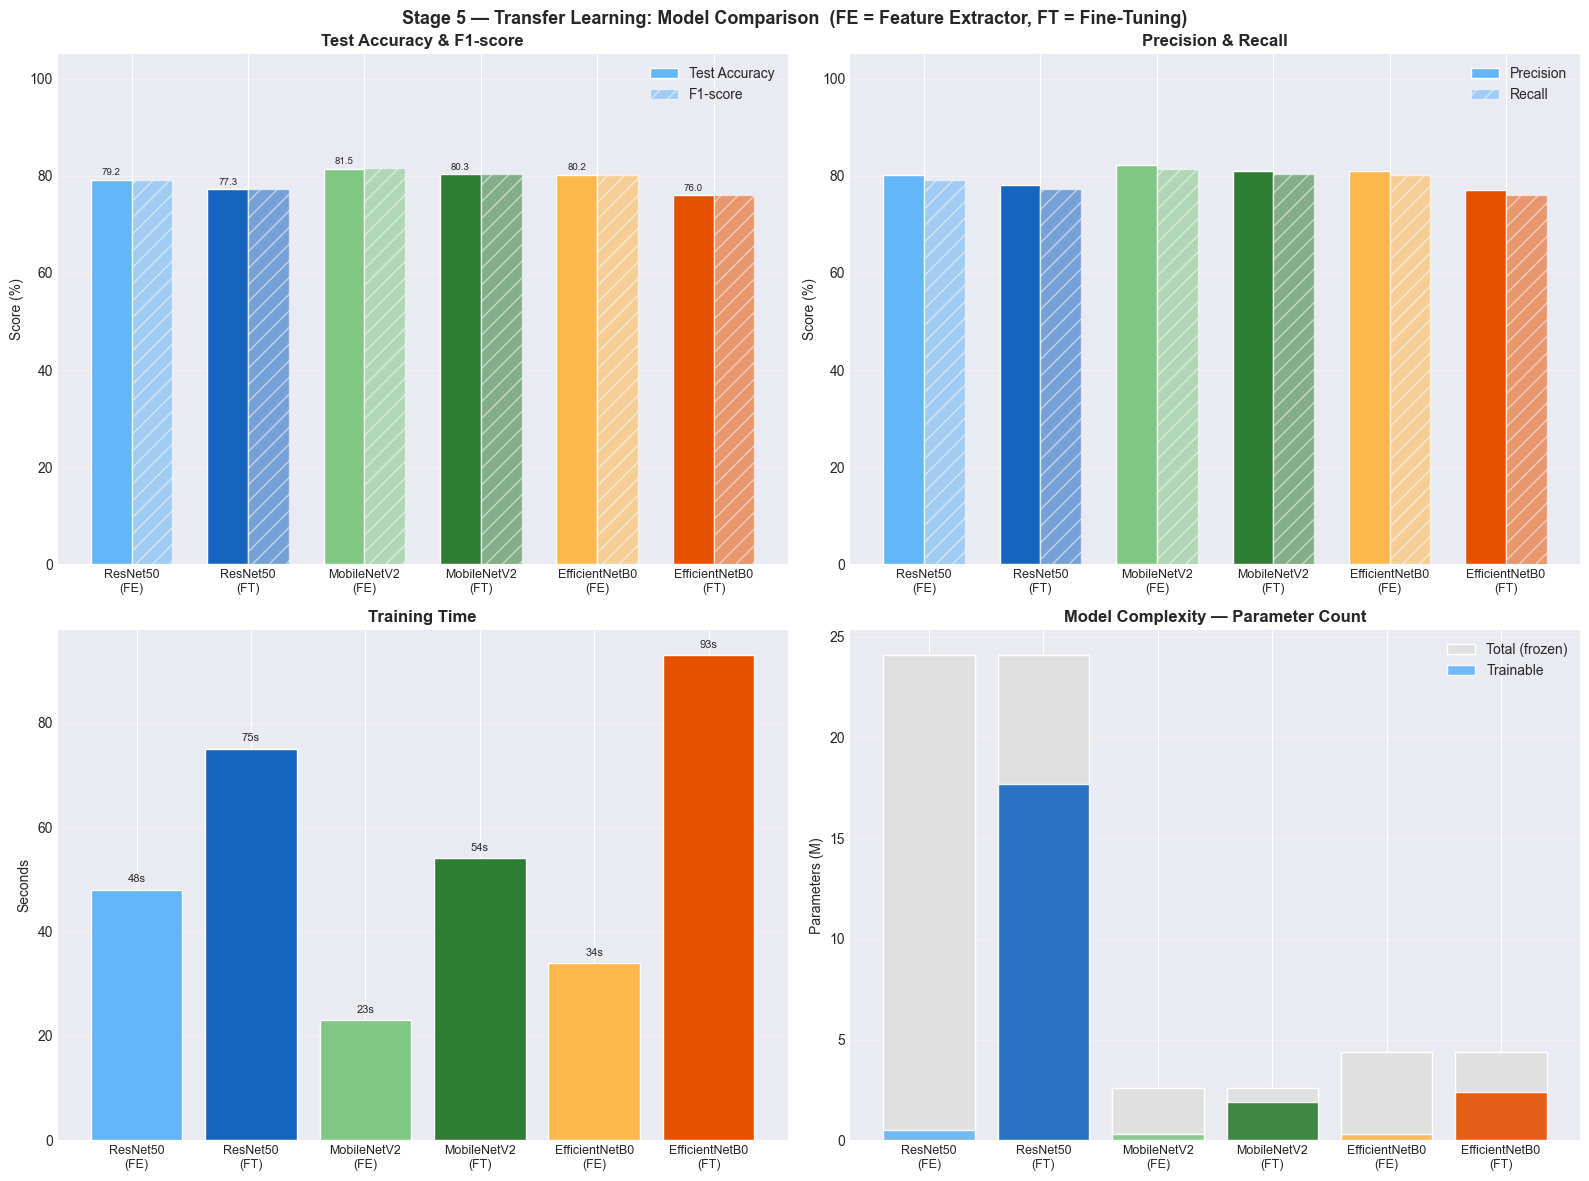


Generalization Analysis  (positive gap ⟹ val > test, negative ⟹ test > val):
Model + Experiment                          Test Acc  Best Val      Gap
────────────────────────────────────────────────────────────────────────
ResNet50 (Feature Extractor)                   79.2%     77.7%    -1.5%
ResNet50 (Fine-Tuning)                         77.3%     75.2%    -2.1%
MobileNetV2 (Feature Extractor)                81.5%     78.5%    -3.0%
MobileNetV2 (Fine-Tuning)                      80.3%     76.0%    -4.3%
EfficientNetB0 (Feature Extractor)             80.2%     80.3%    +0.1%
EfficientNetB0 (Fine-Tuning)                   76.0%     76.0%    +0.0%

───────────────────────────────────────────────────────
  Best F1-score    : MobileNetV2 — Feature Extractor  (81.7%)
  Fastest training : MobileNetV2 — Feature Extractor  (23s)
  Lightest model   : MobileNetV2 — Feature Extractor  (2.6M params)
───────────────────────────────────────────────────────


In [ ]:
# Stage 5 — Transfer Learning: Complete Model Comparison
print('Stage 5 — Transfer Learning: Complete Model Comparison')
print('='*75)

# ── Build comparison DataFrame ───────────────────────────────────────
rows = []
for key, r in tl_results.items():
    rows.append({
        'Model':                r['model_label'],
        'Experiment':           r['experiment'],
        'Accuracy (%)':         round(r['acc']           * 100, 1),
        'Precision (%)':        round(r['precision']      * 100, 1),
        'Recall (%)':           round(r['recall']         * 100, 1),
        'F1-score (%)':         round(r['f1']             * 100, 1),
        'Best Val Acc (%)':     round(r['best_val_acc']   * 100, 1),
        'Train Time (s)':       round(r['train_time'],    0),
        'Total Params (M)':     round(r['total_params']   / 1e6, 1),
        'Trainable Params (M)': round(r['trainable_params'] / 1e6, 1),
    })

df_comp = pd.DataFrame(rows)
print('\n', df_comp.to_string(index=False), '\n')

# ── Colour palette (light = Feature Extractor, dark = Fine-Tuning) ────
_palette = {
    ('ResNet50',       'Feature Extractor'): '#64B5F6',
    ('ResNet50',       'Fine-Tuning'):        '#1565C0',
    ('MobileNetV2',    'Feature Extractor'): '#81C784',
    ('MobileNetV2',    'Fine-Tuning'):        '#2E7D32',
    ('EfficientNetB0', 'Feature Extractor'): '#FFB74D',
    ('EfficientNetB0', 'Fine-Tuning'):        '#E65100',
}
bar_colors = [_palette[(r['Model'], r['Experiment'])] for _, r in df_comp.iterrows()]
labels = [f"{r['Model']}\n({'FE' if r['Experiment']=='Feature Extractor' else 'FT'})"
          for _, r in df_comp.iterrows()]
x = np.arange(len(labels))
w = 0.35

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Stage 5 — Transfer Learning: Model Comparison  (FE = Feature Extractor, FT = Fine-Tuning)',
             fontsize=13, fontweight='bold')

# ── (0,0) Test Accuracy & F1-score ───────────────────────────────────
ax = axes[0, 0]
bars_acc = ax.bar(x - w/2, df_comp['Accuracy (%)'], w, label='Test Accuracy',
                  color=bar_colors, edgecolor='white')
bars_f1  = ax.bar(x + w/2, df_comp['F1-score (%)'],  w, label='F1-score',
                  color=bar_colors, alpha=0.55, hatch='//', edgecolor='white')
for bar in bars_acc:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=7)
ax.set_title('Test Accuracy & F1-score', fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel('Score (%)'); ax.set_ylim(0, 105)
ax.legend(); ax.grid(axis='y', alpha=0.3)

# ── (0,1) Precision & Recall ─────────────────────────────────────────
ax = axes[0, 1]
ax.bar(x - w/2, df_comp['Precision (%)'], w, label='Precision',
       color=bar_colors, edgecolor='white')
ax.bar(x + w/2, df_comp['Recall (%)'],    w, label='Recall',
       color=bar_colors, alpha=0.55, hatch='//', edgecolor='white')
ax.set_title('Precision & Recall', fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel('Score (%)'); ax.set_ylim(0, 105)
ax.legend(); ax.grid(axis='y', alpha=0.3)

# ── (1,0) Training time ───────────────────────────────────────────────
ax = axes[1, 0]
bars_t = ax.bar(x, df_comp['Train Time (s)'], color=bar_colors, edgecolor='white')
for bar in bars_t:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{bar.get_height():.0f}s', ha='center', va='bottom', fontsize=8)
ax.set_title('Training Time', fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel('Seconds'); ax.grid(axis='y', alpha=0.3)

# ── (1,1) Model complexity ────────────────────────────────────────────
ax = axes[1, 1]
ax.bar(x, df_comp['Total Params (M)'],     label='Total (frozen)',
       color='#E0E0E0', edgecolor='white')
ax.bar(x, df_comp['Trainable Params (M)'], label='Trainable',
       color=bar_colors, edgecolor='white', alpha=0.9)
ax.set_title('Model Complexity — Parameter Count', fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel('Parameters (M)'); ax.legend(); ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# ── Generalization analysis ───────────────────────────────────────────
print('\nGeneralization Analysis  (positive gap ⟹ val > test, negative ⟹ test > val):')
print(f'{"Model + Experiment":<42} {"Test Acc":>9} {"Best Val":>9} {"Gap":>8}')
print('─' * 72)
for _, row in df_comp.iterrows():
    gap   = row['Best Val Acc (%)'] - row['Accuracy (%)']
    label = f"{row['Model']} ({row['Experiment']})"
    print(f'{label:<42} {row["Accuracy (%)"]:>8.1f}% {row["Best Val Acc (%)"]:>8.1f}% {gap:>+7.1f}%')

# ── Best performer summary ────────────────────────────────────────────
best_idx = df_comp['F1-score (%)'].idxmax()
best     = df_comp.loc[best_idx]
fastest  = df_comp.loc[df_comp['Train Time (s)'].idxmin()]
lightest = df_comp.loc[df_comp['Total Params (M)'].idxmin()]

print('\n' + '─'*55)
print(f'  Best F1-score    : {best["Model"]} — {best["Experiment"]}  ({best["F1-score (%)"]:.1f}%)')
print(f'  Fastest training : {fastest["Model"]} — {fastest["Experiment"]}  ({fastest["Train Time (s)"]:.0f}s)')
print(f'  Lightest model   : {lightest["Model"]} — {lightest["Experiment"]}  ({lightest["Total Params (M)"]:.1f}M params)')
print('─'*55)

## Stage 5 — Transfer Learning: Interpretation of Results

### Models Chosen

| Model | Architecture | Why included in comparison |
|-------|-------------|----------------------------|
| **ResNet50** | Deep residual network | Strong high-capacity baseline with rich features |
| **MobileNetV2** | Inverted residual + depthwise separable convolutions | Lightweight, fast, and parameter-efficient |
| **EfficientNetB0** | Compound-scaled CNN | Balanced accuracy/efficiency baseline |

These three models cover a useful spectrum: high capacity (ResNet50), lightweight (MobileNetV2), and balanced efficiency (EfficientNetB0).

---

### Experiment Design (What was tested)

**Experiment A — Feature Extractor (FE)**
- Backbone frozen.
- Only the custom head is trained.
- Higher learning rate (`1e-3`) is used safely because pretrained weights are not updated.

**Experiment B — Fine-Tuning (FT)**
- Two-phase training: short warm-up, then partial unfreezing of top layers.
- Small learning rate (`1e-5`) during fine-tuning to avoid damaging pretrained features.
- Backbone called with `training=False`, so pretrained BatchNorm statistics remain fixed during forward passes.


---

### What the current run shows (from the comparison table/plots above)

| Criterion | Observation in this run |
|-----------|--------------------------|
| **Best test accuracy / F1** | **MobileNetV2 (Feature Extractor)** |
| **Fastest training** | **MobileNetV2 (Feature Extractor)** |
| **Largest model** | ResNet50 |
| **Smallest model** | MobileNetV2 |

### FE vs FT in this run
For all three backbones, **Feature Extractor performed better than Fine-Tuning on test metrics**. That means unfreezing top layers did not improve generalization here and added training cost.

Likely reasons include:
- The dataset size is moderate, so partial fine-tuning can over-specialize quickly.
- The chosen unfreeze depth and learning-rate schedule may be too aggressive for this data.
- Keeping BatchNorm in inference mode while fine-tuning can stabilize training but may limit adaptation in some settings.

### Practical takeaway
For this specific notebook run, **MobileNetV2 as a frozen feature extractor is the strongest overall choice** (best performance with the lowest cost). Fine-tuning is still a valid strategy, but it should be re-tuned (unfreeze depth, epochs, LR schedule, regularization) before concluding it is better for this dataset.

### Validity note
These conclusions are tied to this split/seed/run. For stronger evidence, repeat with multiple seeds (or cross-validation) and compare mean performance and variance.

# Stage 6: Comparative Scientific Analysis

This stage compares all available trained models using:
- Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix
- Training time
- Model size

It also analyzes:
- Best-performing model
- Weakest classes
- Misclassification cases
- Overfitting behavior
- Speed vs accuracy tradeoff

In [32]:
# Stage 6 — Collect metrics for all available models (simple, unified pipeline)
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support, accuracy_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

g = globals()
evaluations = []

def evaluate_model(model_name, model_obj, X_eval, y_true, history_obj=None, train_time=np.nan):
    y_pred = np.argmax(model_obj.predict(X_eval, verbose=0), axis=1)
    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='weighted', zero_division=0
    )

    total_params = int(model_obj.count_params())
    model_size_mb = (total_params * 4) / (1024 ** 2)  # float32 approximation

    overfit_gap = np.nan
    if history_obj is not None:
        if hasattr(history_obj, 'history'):
            hist = history_obj.history
        else:
            hist = history_obj
        if 'accuracy' in hist and 'val_accuracy' in hist and len(hist['accuracy']) > 0:
            overfit_gap = float(hist['accuracy'][-1] - max(hist['val_accuracy']))

    evaluations.append({
        'Model': model_name,
        'Accuracy': float(acc),
        'Precision': float(prec),
        'Recall': float(rec),
        'F1-score': float(f1),
        'Training time (s)': float(train_time) if train_time == train_time else np.nan,
        'Model size (MB)': float(model_size_mb),
        'Total params': total_params,
        'Overfitting gap (train - best val)': overfit_gap,
        'y_pred': y_pred
    })

# Stage 2 models
if 'custom_cnn' in g and 'X_test' in g and 'y_test' in g and 'history_dict' in g:
    evaluate_model('Custom CNN (Baseline)', custom_cnn, X_test, y_test, history_dict, np.nan)

if 'regularized_cnn' in g and 'X_test' in g and 'y_test' in g and 'reg_dict' in g:
    evaluate_model('Custom CNN (Regularized)', regularized_cnn, X_test, y_test, reg_dict, np.nan)

# Stage 5 models
if all(k in g for k in ['model_r50_A', 'tl_data', 'y_test', 'hist_r50_A', 'time_r50_A']):
    evaluate_model('ResNet50 (Feature Extractor)', model_r50_A, tl_data['resnet50']['test'], y_test, hist_r50_A, time_r50_A)
if all(k in g for k in ['model_r50_B', 'tl_data', 'y_test', 'hist_r50_B', 'time_r50_B']):
    evaluate_model('ResNet50 (Fine-Tuned)', model_r50_B, tl_data['resnet50']['test'], y_test, hist_r50_B, time_r50_B)

if all(k in g for k in ['model_mv2_A', 'tl_data', 'y_test', 'hist_mv2_A', 'time_mv2_A']):
    evaluate_model('MobileNetV2 (Feature Extractor)', model_mv2_A, tl_data['mobilenetv2']['test'], y_test, hist_mv2_A, time_mv2_A)
if all(k in g for k in ['model_mv2_B', 'tl_data', 'y_test', 'hist_mv2_B', 'time_mv2_B']):
    evaluate_model('MobileNetV2 (Fine-Tuned)', model_mv2_B, tl_data['mobilenetv2']['test'], y_test, hist_mv2_B, time_mv2_B)

if all(k in g for k in ['model_eff_A', 'tl_data', 'y_test', 'hist_eff_A', 'time_eff_A']):
    evaluate_model('EfficientNetB0 (Feature Extractor)', model_eff_A, tl_data['efficientnetb0']['test'], y_test, hist_eff_A, time_eff_A)
if all(k in g for k in ['model_eff_B', 'tl_data', 'y_test', 'hist_eff_B', 'time_eff_B']):
    evaluate_model('EfficientNetB0 (Fine-Tuned)', model_eff_B, tl_data['efficientnetb0']['test'], y_test, hist_eff_B, time_eff_B)

# Build a clean comparison table
results_df = pd.DataFrame(evaluations)
if len(results_df) == 0:
    print('No trained models found in memory. Run Stage 2/3/5 cells first, then re-run this cell.')
else:
    results_df = results_df.sort_values('F1-score', ascending=False).reset_index(drop=True)
    display_cols = [
        'Model', 'Accuracy', 'Precision', 'Recall', 'F1-score',
        'Training time (s)', 'Model size (MB)', 'Total params', 'Overfitting gap (train - best val)'
    ]
    print('Stage 6 — Unified Model Comparison')
    display(results_df[display_cols].round(4))

    if results_df['Training time (s)'].isna().any():
        print('Note: Some models show missing training time because timing was not recorded during fit.')

Stage 6 — Unified Model Comparison


,Model,Accuracy,Precision,Recall,F1-score,Training time (s),Model size (MB),Total params,Overfitting gap (train - best val)
0,MobileNetV2 (Feature Extractor),0.8150,0.8219,0.8150,0.8169,23.3209,9.8743,2588490,0.1414
1,MobileNetV2 (Fine-Tuned),0.8033,0.8111,0.8033,0.8039,54.4297,9.8743,2588490,0.1057
2,EfficientNetB0 (Feature Extractor),0.8017,0.8094,0.8017,0.8017,33.9979,16.7087,4380077,0.1649
3,ResNet50 (Feature Extractor),0.7917,0.8007,0.7917,0.7907,48.3570,91.9908,24114826,0.1576
4,ResNet50 (Fine-Tuned),0.7733,0.7817,0.7733,0.7732,75.3879,91.9908,24114826,0.1962
5,EfficientNetB0 (Fine-Tuned),0.7600,0.7713,0.7600,0.7597,92.7649,16.7087,4380077,0.0921
6,Custom CNN (Regularized),0.3667,0.4552,0.3667,0.3503,NaN,16.3665,4290378,0.2608
7,Custom CNN (Baseline),0.2083,0.3034,0.2083,0.1921,NaN,16.3611,4288970,0.2313


Note: Some models show missing training time because timing was not recorded during fit.


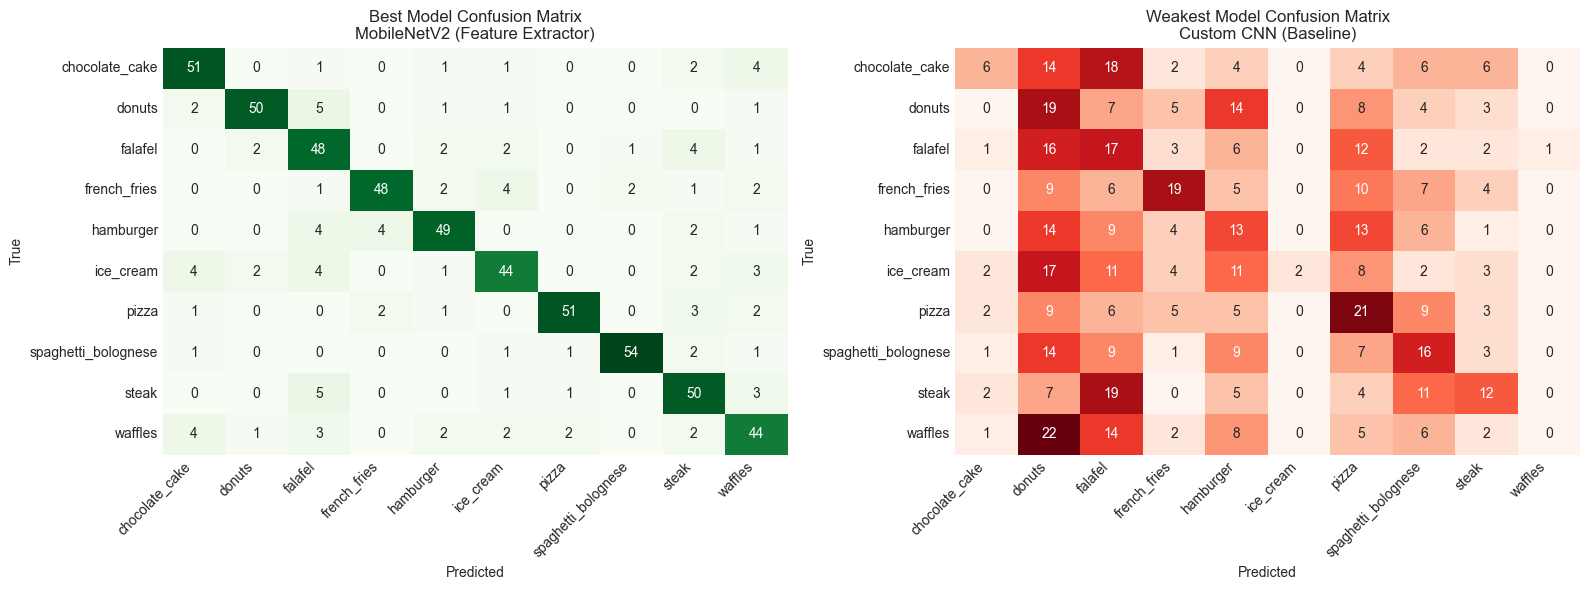

Best-performing model (by F1-score): MobileNetV2 (Feature Extractor)
Weakest classes for the best model (lowest recall):
- ice_cream: recall=0.733, most confused with chocolate_cake
- waffles: recall=0.733, most confused with chocolate_cake
- falafel: recall=0.800, most confused with steak

Misclassification cases found for best model: 111


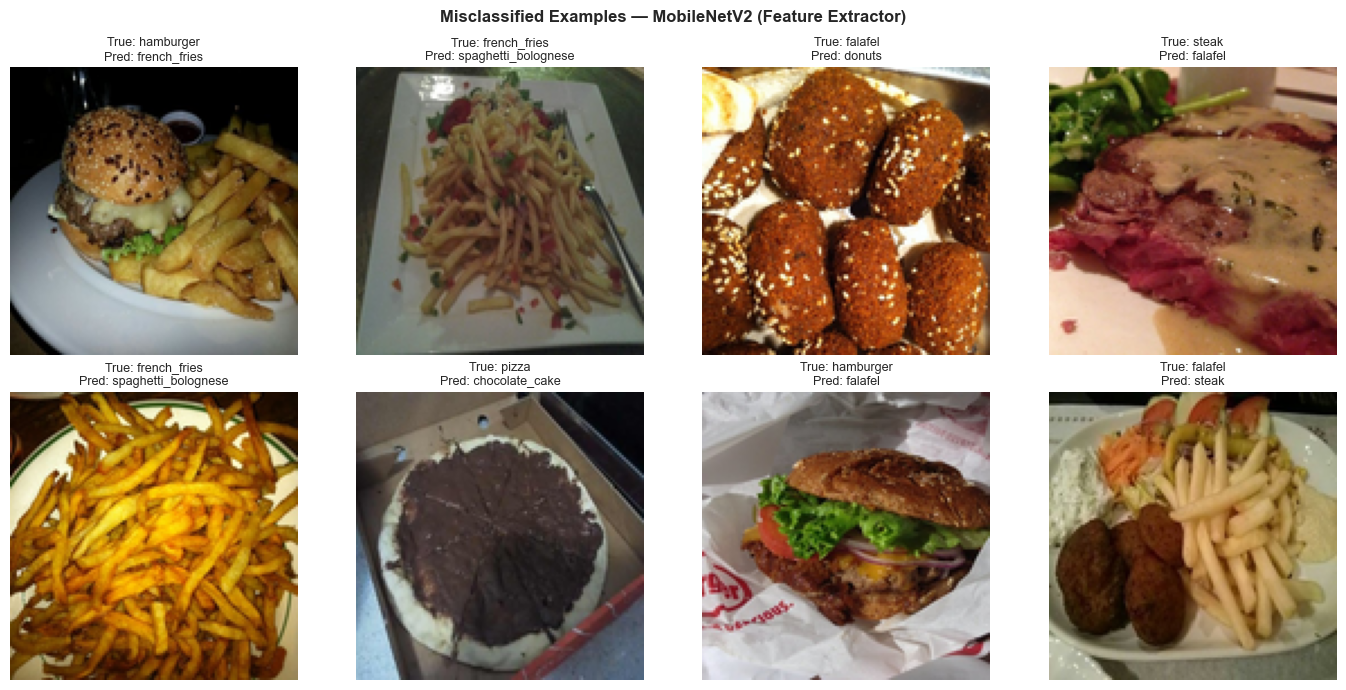


Overfitting behavior (positive gap = more overfitting):


,Model,Overfitting gap (train - best val)
6,Custom CNN (Regularized),0.2608
7,Custom CNN (Baseline),0.2313
4,ResNet50 (Fine-Tuned),0.1962
2,EfficientNetB0 (Feature Extractor),0.1649
3,ResNet50 (Feature Extractor),0.1576
0,MobileNetV2 (Feature Extractor),0.1414
1,MobileNetV2 (Fine-Tuned),0.1057
5,EfficientNetB0 (Fine-Tuned),0.0921


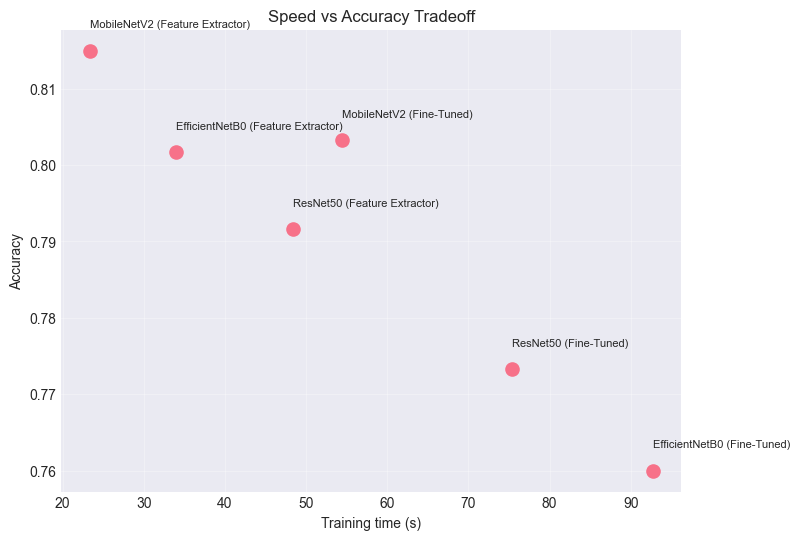

Fastest (timed) model: MobileNetV2 (Feature Extractor) (23s)
Most accurate (timed) model: MobileNetV2 (Feature Extractor) (81.5%)


In [33]:
# Stage 6 — Confusion matrices, weakest classes, misclassifications, and tradeoff analysis
if 'results_df' not in globals() or len(results_df) == 0:
    print('Run the previous Stage 6 cell first.')
else:
    # Identify best model by F1-score
    best_model_name = results_df.iloc[0]['Model']
    worst_model_name = results_df.iloc[-1]['Model']

    best_pred = results_df.loc[results_df['Model'] == best_model_name, 'y_pred'].values[0]
    worst_pred = results_df.loc[results_df['Model'] == worst_model_name, 'y_pred'].values[0]

    cm_best = confusion_matrix(y_test, best_pred)
    cm_worst = confusion_matrix(y_test, worst_pred)

    # 1) Confusion matrices: best vs weakest model
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    sns.heatmap(cm_best, annot=True, fmt='d', cmap='Greens', cbar=False, ax=axes[0])
    axes[0].set_title(f'Best Model Confusion Matrix\n{best_model_name}')
    axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')
    axes[0].set_xticklabels(class_names, rotation=45, ha='right')
    axes[0].set_yticklabels(class_names, rotation=0)

    sns.heatmap(cm_worst, annot=True, fmt='d', cmap='Reds', cbar=False, ax=axes[1])
    axes[1].set_title(f'Weakest Model Confusion Matrix\n{worst_model_name}')
    axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')
    axes[1].set_xticklabels(class_names, rotation=45, ha='right')
    axes[1].set_yticklabels(class_names, rotation=0)

    plt.tight_layout()
    plt.show()

    # 2) Weakest classes (lowest recall) for best model
    per_class_recall = np.diag(cm_best) / np.maximum(cm_best.sum(axis=1), 1)
    weakest_idx = np.argsort(per_class_recall)[:3]

    print('Best-performing model (by F1-score):', best_model_name)
    print('Weakest classes for the best model (lowest recall):')
    for idx in weakest_idx:
        row = cm_best[idx].copy()
        row[idx] = -1
        confused_as = int(np.argmax(row))
        print(f"- {class_names[idx]}: recall={per_class_recall[idx]:.3f}, most confused with {class_names[confused_as]}")

    # 3) Misclassification cases from the best model
    mis_idx = np.where(best_pred != y_test)[0]
    print(f'\nMisclassification cases found for best model: {len(mis_idx)}')

    if len(mis_idx) > 0:
        n_show = min(8, len(mis_idx))
        fig, axes = plt.subplots(2, 4, figsize=(14, 7))
        axes = axes.flatten()
        for i in range(8):
            axes[i].axis('off')
        for i, m in enumerate(mis_idx[:n_show]):
            axes[i].imshow(X_test[m])
            axes[i].set_title(
                f"True: {class_names[y_test[m]]}\nPred: {class_names[best_pred[m]]}",
                fontsize=9
            )
            axes[i].axis('off')
        plt.suptitle(f'Misclassified Examples — {best_model_name}', fontsize=12, fontweight='bold')
        plt.tight_layout()
        plt.show()

    # 4) Overfitting behavior summary
    print('\nOverfitting behavior (positive gap = more overfitting):')
    overfit_view = results_df[['Model', 'Overfitting gap (train - best val)']].copy()
    overfit_view = overfit_view.sort_values('Overfitting gap (train - best val)', ascending=False)
    display(overfit_view.round(4))

    # 5) Speed vs accuracy tradeoff
    speed_df = results_df.dropna(subset=['Training time (s)']).copy()
    if len(speed_df) > 0:
        plt.figure(figsize=(8, 6))
        plt.scatter(speed_df['Training time (s)'], speed_df['Accuracy'], s=90)
        for _, r in speed_df.iterrows():
            plt.text(r['Training time (s)'], r['Accuracy'] + 0.003, r['Model'], fontsize=8)
        plt.xlabel('Training time (s)')
        plt.ylabel('Accuracy')
        plt.title('Speed vs Accuracy Tradeoff')
        plt.grid(alpha=0.3)
        plt.show()

        fastest = speed_df.loc[speed_df['Training time (s)'].idxmin()]
        most_accurate = speed_df.loc[speed_df['Accuracy'].idxmax()]
        print(f"Fastest (timed) model: {fastest['Model']} ({fastest['Training time (s)']:.0f}s)")
        print(f"Most accurate (timed) model: {most_accurate['Model']} ({most_accurate['Accuracy']*100:.1f}%)")
    else:
        print('\nNo timed models available for speed-accuracy plot.')

## Augmented Image Samples

This visualization shows one original training image and multiple augmented versions generated by the Stage 3 augmentation pipeline.

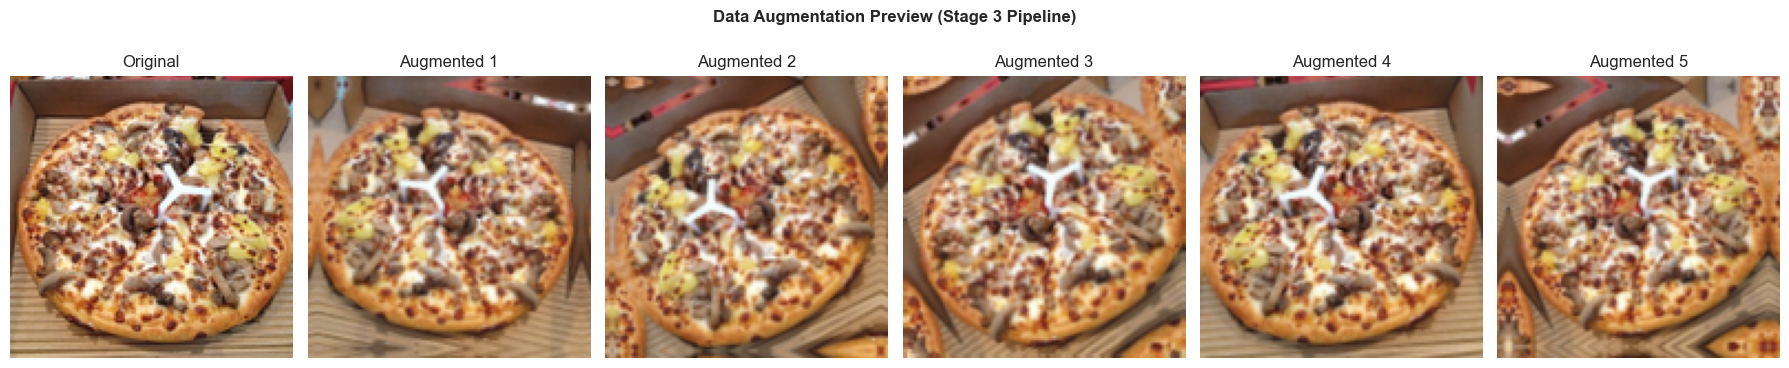

In [34]:
# This cell visualizes data augmentation outputs required in the report.
# It shows one original image and several augmented variants.

import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

if 'data_augmentation' not in globals():
    print("data_augmentation is not defined. Run the Stage 3 setup cell first.")
elif 'X_train' not in globals() or len(X_train) == 0:
    print("X_train is not available. Run the data loading/splitting cells first.")
else:
    # Pick one sample image from training data
    sample_idx = 0
    original_img = X_train[sample_idx]

    # Generate augmented versions of the same image
    n_augmented = 5
    augmented_imgs = []
    for _ in range(n_augmented):
        aug = data_augmentation(tf.expand_dims(original_img, axis=0), training=True)
        augmented_imgs.append(tf.squeeze(aug, axis=0).numpy())

    # Plot: original + augmented images
    fig, axes = plt.subplots(1, n_augmented + 1, figsize=(18, 4))
    axes[0].imshow(np.clip(original_img, 0, 1))
    axes[0].set_title("Original")
    axes[0].axis("off")

    for i in range(n_augmented):
        axes[i + 1].imshow(np.clip(augmented_imgs[i], 0, 1))
        axes[i + 1].set_title(f"Augmented {i+1}")
        axes[i + 1].axis("off")

    plt.suptitle("Data Augmentation Preview (Stage 3 Pipeline)", fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [36]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

results = []

for key, r in tl_results.items():

    y_pred = r['y_pred']

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

   
    print(r['model_label'], "-", r['experiment'])

    print("Accuracy :", accuracy)
    print("Precision:", precision)
    print("Recall   :", recall)
    print("F1-Score :", f1)
    print("Training Time:", r['time_sec'])
    print("Model Size:", r['params'])

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(8,6))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names
    )

    plt.title(r['model_label'] + " " + r['experiment'])
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.xticks(rotation=45)
    plt.yticks(rotation=45)

    plt.tight_layout()
    plt.show()

    results.append({
        'Model': r['model_label'] + ' ' + r['experiment'],
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'Training Time': r['time_sec'],
        'Model Size': r['params']
    })

comparison_df = pd.DataFrame(results)

print("\nFinal Comparison")
print(comparison_df)

best_model = comparison_df.iloc[comparison_df['Accuracy'].idxmax()]

print("\nBest Performing Model:")
print(best_model['Model'])

KeyError: 'y_pred'